In [1]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


# Problem definiton
**Segmentation of gliomas in pre-operative MRI scans.**

*Each pixel on image must be labeled:*
* Pixel is part of a tumor area (1 or 2 or 3) -> can be one of multiple classes / sub-regions
* Anything else -> pixel is not on a tumor region (0)

The sub-regions of tumor considered for evaluation are: 1) the "enhancing tumor" (ET), 2) the "tumor core" (TC), and 3) the "whole tumor" (WT)
The provided segmentation labels have values of 1 for NCR & NET, 2 for ED, 4 for ET, and 0 for everything else.



In [2]:
!pip install keras matplotlib nibabel nilearn numpy opencv-python pandas pydot scikit-image seaborn tensorflow tensorflow-addons

ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)
ERROR: No matching distribution found for tensorflow-addons


![Brats official annotations](https://www.med.upenn.edu/cbica/assets/user-content/images/BraTS/brats-tumor-subregions.jpg)

In [3]:
!pip install nilearn
!pip install tensorflow

# Setup env

In [4]:
import os
import cv2
import glob
import PIL
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skimage import data
from skimage.util import montage
import skimage.transform as skTrans
from skimage.transform import rotate
from skimage.transform import resize
from PIL import Image, ImageOps


# neural imaging
import nilearn as nl
import nibabel as nib
import nilearn.plotting as nlplt



# ml libs
import keras
import keras.backend as K
from keras.callbacks import CSVLogger
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, TensorBoard
#from tensorflow.keras.layers import preprocessing
#from tensorflow.keras.layers import Rescaling, RandomFlip, RandomRotation


# Make numpy printouts easier to read.
np.set_printoptions(precision=3, suppress=True)

In [5]:
# DEFINE seg-areas
SEGMENT_CLASSES = {
    0 : 'NOT tumor',
    1 : 'NECROTIC/CORE', # or NON-ENHANCING tumor CORE
    2 : 'EDEMA',
    3 : 'ENHANCING' # original 4 -> converted into 3 later
}

# there are 155 slices per volume
# to start at 5 and use 145 slices means we will skip the first 5 and last 5
VOLUME_SLICES = 75
VOLUME_START_AT = 40 # first slice of volume that we will include

# Image data descriptions

All BraTS multimodal scans are available as  NIfTI files (.nii.gz) -> commonly used medical imaging format to store brain imagin data obtained using MRI and describe different MRI settings
1. **T1**: T1-weighted, native image, sagittal or axial 2D acquisitions, with 1–6 mm slice thickness.
2. **T1c**: T1-weighted, contrast-enhanced (Gadolinium) image, with 3D acquisition and 1 mm isotropic voxel size for most patients.
3. **T2**: T2-weighted image, axial 2D acquisition, with 2–6 mm slice thickness.
4. **FLAIR**: T2-weighted FLAIR image, axial, coronal, or sagittal 2D acquisitions, 2–6 mm slice thickness.

Data were acquired with different clinical protocols and various scanners from multiple (n=19) institutions.

All the imaging datasets have been segmented manually, by one to four raters, following the same annotation protocol, and their annotations were approved by experienced neuro-radiologists. Annotations comprise the GD-enhancing tumor (ET — label 4), the peritumoral edema (ED — label 2), and the necrotic and non-enhancing tumor core (NCR/NET — label 1), as described both in the BraTS 2012-2013 TMI paper and in the latest BraTS summarizing paper. The provided data are distributed after their pre-processing, i.e., co-registered to the same anatomical template, interpolated to the same resolution (1 mm^3) and skull-stripped.



In [6]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("awsaf49/brats20-dataset-training-validation")

print("Path to dataset files:", path)
print('Data source import complete.')
print("Contents of data path:", os.listdir(path))

Using Colab cache for faster access to the 'brats20-dataset-training-validation' dataset.
Path to dataset files: /kaggle/input/brats20-dataset-training-validation
Data source import complete.
Contents of data path: ['BraTS2020_ValidationData', 'BraTS2020_TrainingData']


Text(0.5, 1.0, 'Mask')

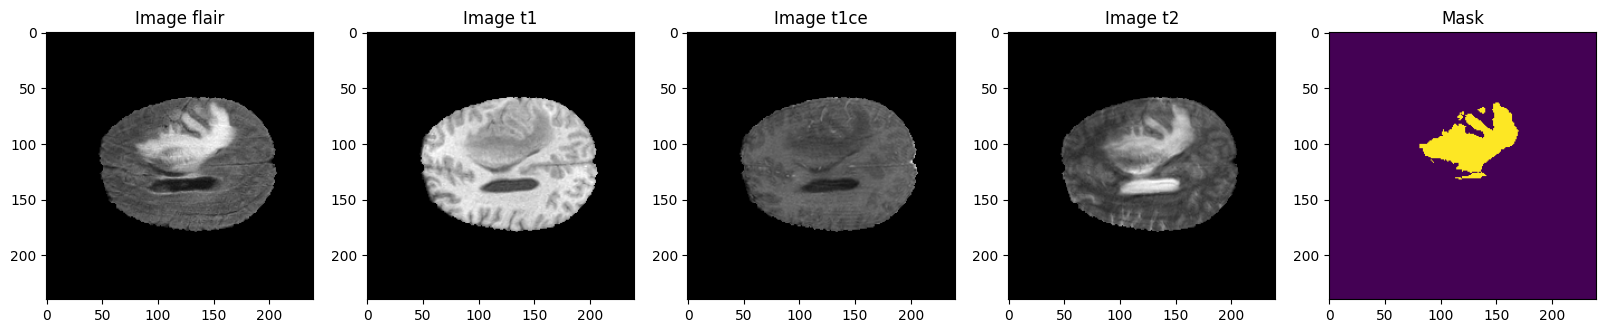

In [7]:
"""
TRAIN_DATASET_PATH = '/root/.cache/kagglehub/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/'
VALIDATION_DATASET_PATH = '/root/.cache/kagglehub/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/'
"""
# Đường dẫn gốc (dựa trên output của cell 11 bạn đã chạy)
BASE_PATH = '/kaggle/input/brats20-dataset-training-validation'

# Cập nhật đường dẫn chính xác (bỏ 'versions/1/' và sửa lỗi thừa khoảng trắng)
TRAIN_DATASET_PATH = BASE_PATH + '/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/'
VALIDATION_DATASET_PATH = BASE_PATH + '/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/'

test_image_flair=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_flair.nii').get_fdata()
test_image_t1=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_t1.nii').get_fdata()
test_image_t1ce=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_t1ce.nii').get_fdata()
test_image_t2=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_t2.nii').get_fdata()
test_mask=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_seg.nii').get_fdata()


fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1,5, figsize = (20, 10))
slice_w = 25
ax1.imshow(test_image_flair[:,:,test_image_flair.shape[0]//2-slice_w], cmap = 'gray')
ax1.set_title('Image flair')
ax2.imshow(test_image_t1[:,:,test_image_t1.shape[0]//2-slice_w], cmap = 'gray')
ax2.set_title('Image t1')
ax3.imshow(test_image_t1ce[:,:,test_image_t1ce.shape[0]//2-slice_w], cmap = 'gray')
ax3.set_title('Image t1ce')
ax4.imshow(test_image_t2[:,:,test_image_t2.shape[0]//2-slice_w], cmap = 'gray')
ax4.set_title('Image t2')
ax5.imshow(test_mask[:,:,test_mask.shape[0]//2-slice_w])
ax5.set_title('Mask')


**Show whole nifti data -> print each slice from 3d data**

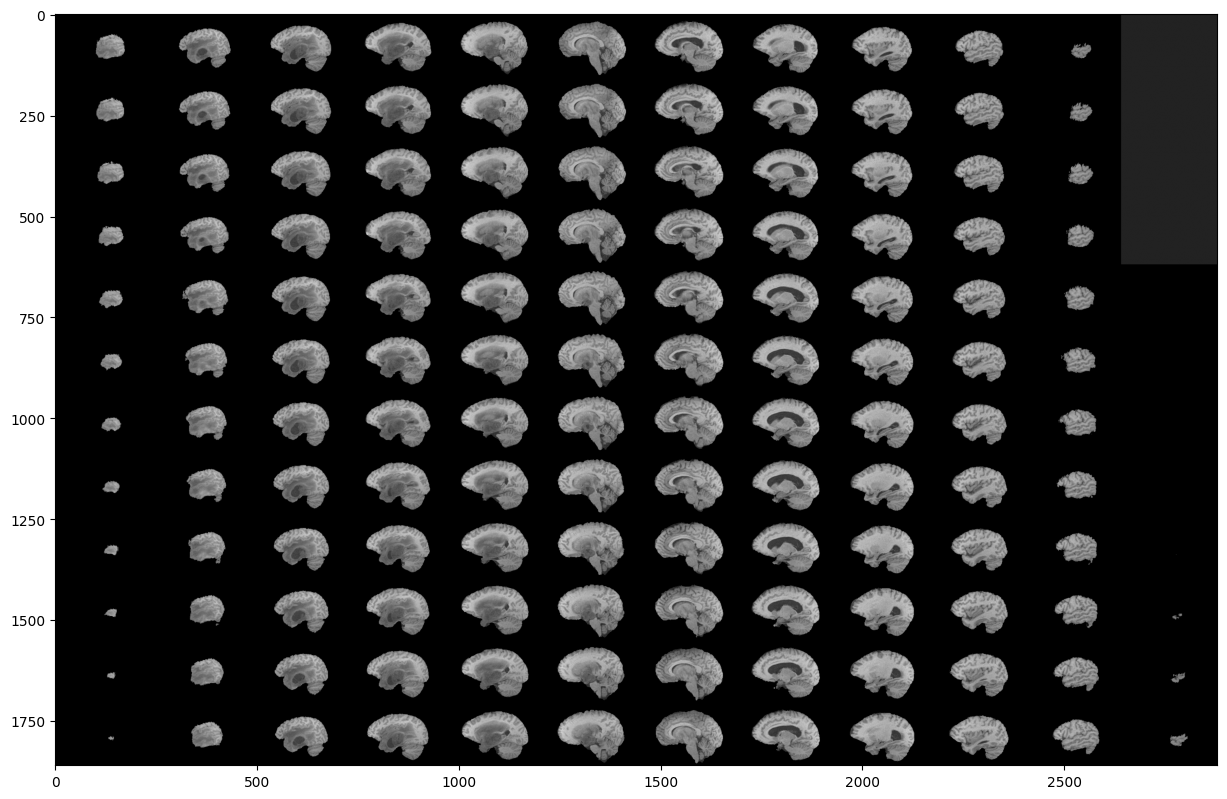

In [8]:
# Skip 50:-50 slices since there is not much to see
fig, ax1 = plt.subplots(1, 1, figsize = (15,15))
ax1.imshow(rotate(montage(test_image_t1[50:-50,:,:]), 90, resize=True), cmap ='gray')

**Show segment of tumor for each above slice**

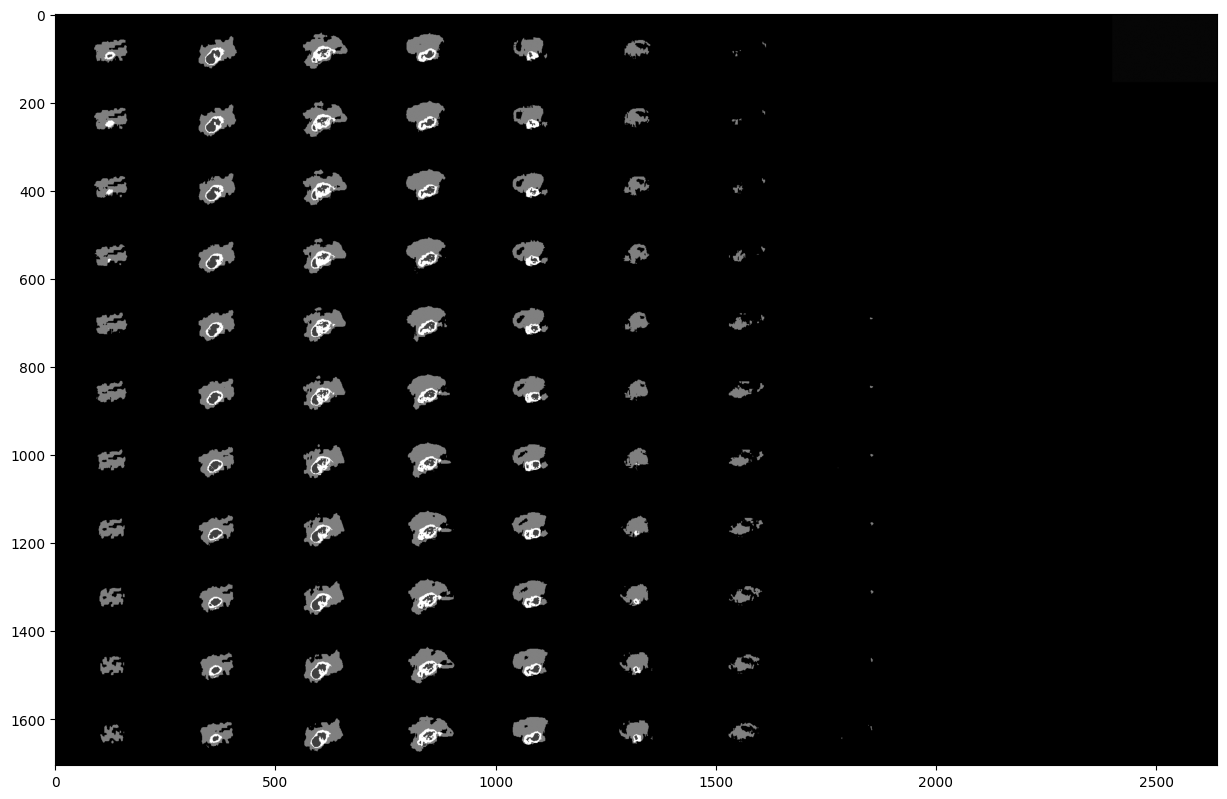

In [9]:
# Skip 50:-50 slices since there is not much to see
fig, ax1 = plt.subplots(1, 1, figsize = (15,15))
ax1.imshow(rotate(montage(test_mask[60:-60,:,:]), 90, resize=True), cmap ='gray')

In [10]:
import imageio
class gif2nif:
    @staticmethod
    def write_gif_normal(path):
        """
        Đọc file .nii và lưu thành file .gif tại cùng đường dẫn
        """
        # Load dữ liệu ảnh
        image = nib.load(path).get_fdata()

        # Chuẩn hóa dữ liệu về dạng 0-255 để hiển thị ảnh
        # Tránh chia cho 0 bằng cách cộng thêm 1e-5
        data_max = np.max(image)
        data_min = np.min(image)
        image = (image - data_min) / (data_max - data_min + 1e-5) * 255
        image = image.astype(np.uint8)

        # Tạo danh sách các frame (lát cắt)
        images = []
        # Lặp qua trục thứ 2 (độ sâu/lát cắt của sọ não)
        for i in range(image.shape[2]):
            # Xoay ảnh 90 độ để nhìn đúng chiều (tùy chỉnh theo dataset BraTS)
            frame = np.rot90(image[:, :, i])
            images.append(frame)

        # Tên file đầu ra (thay đuôi .nii thành .gif)
        output_path = path.replace('.nii', '.gif')

        # Lưu file gif
        imageio.mimsave(output_path, images, duration=0.1) # duration là tốc độ chuyển frame
        print(f"Đã lưu GIF tại: {output_path}")
        return output_path

In [11]:
shutil.copy2(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_flair.nii', './test_gif_BraTS20_Training_001_flair.nii')
gif2nif.write_gif_normal('./test_gif_BraTS20_Training_001_flair.nii')

Đã lưu GIF tại: ./test_gif_BraTS20_Training_001_flair.gif


'./test_gif_BraTS20_Training_001_flair.gif'

**Gif representation of slices in 3D volume**
<img src="https://media1.tenor.com/images/15427ffc1399afc3334f12fd27549a95/tenor.gif?itemid=20554734">

**Show segments of tumor using different effects**

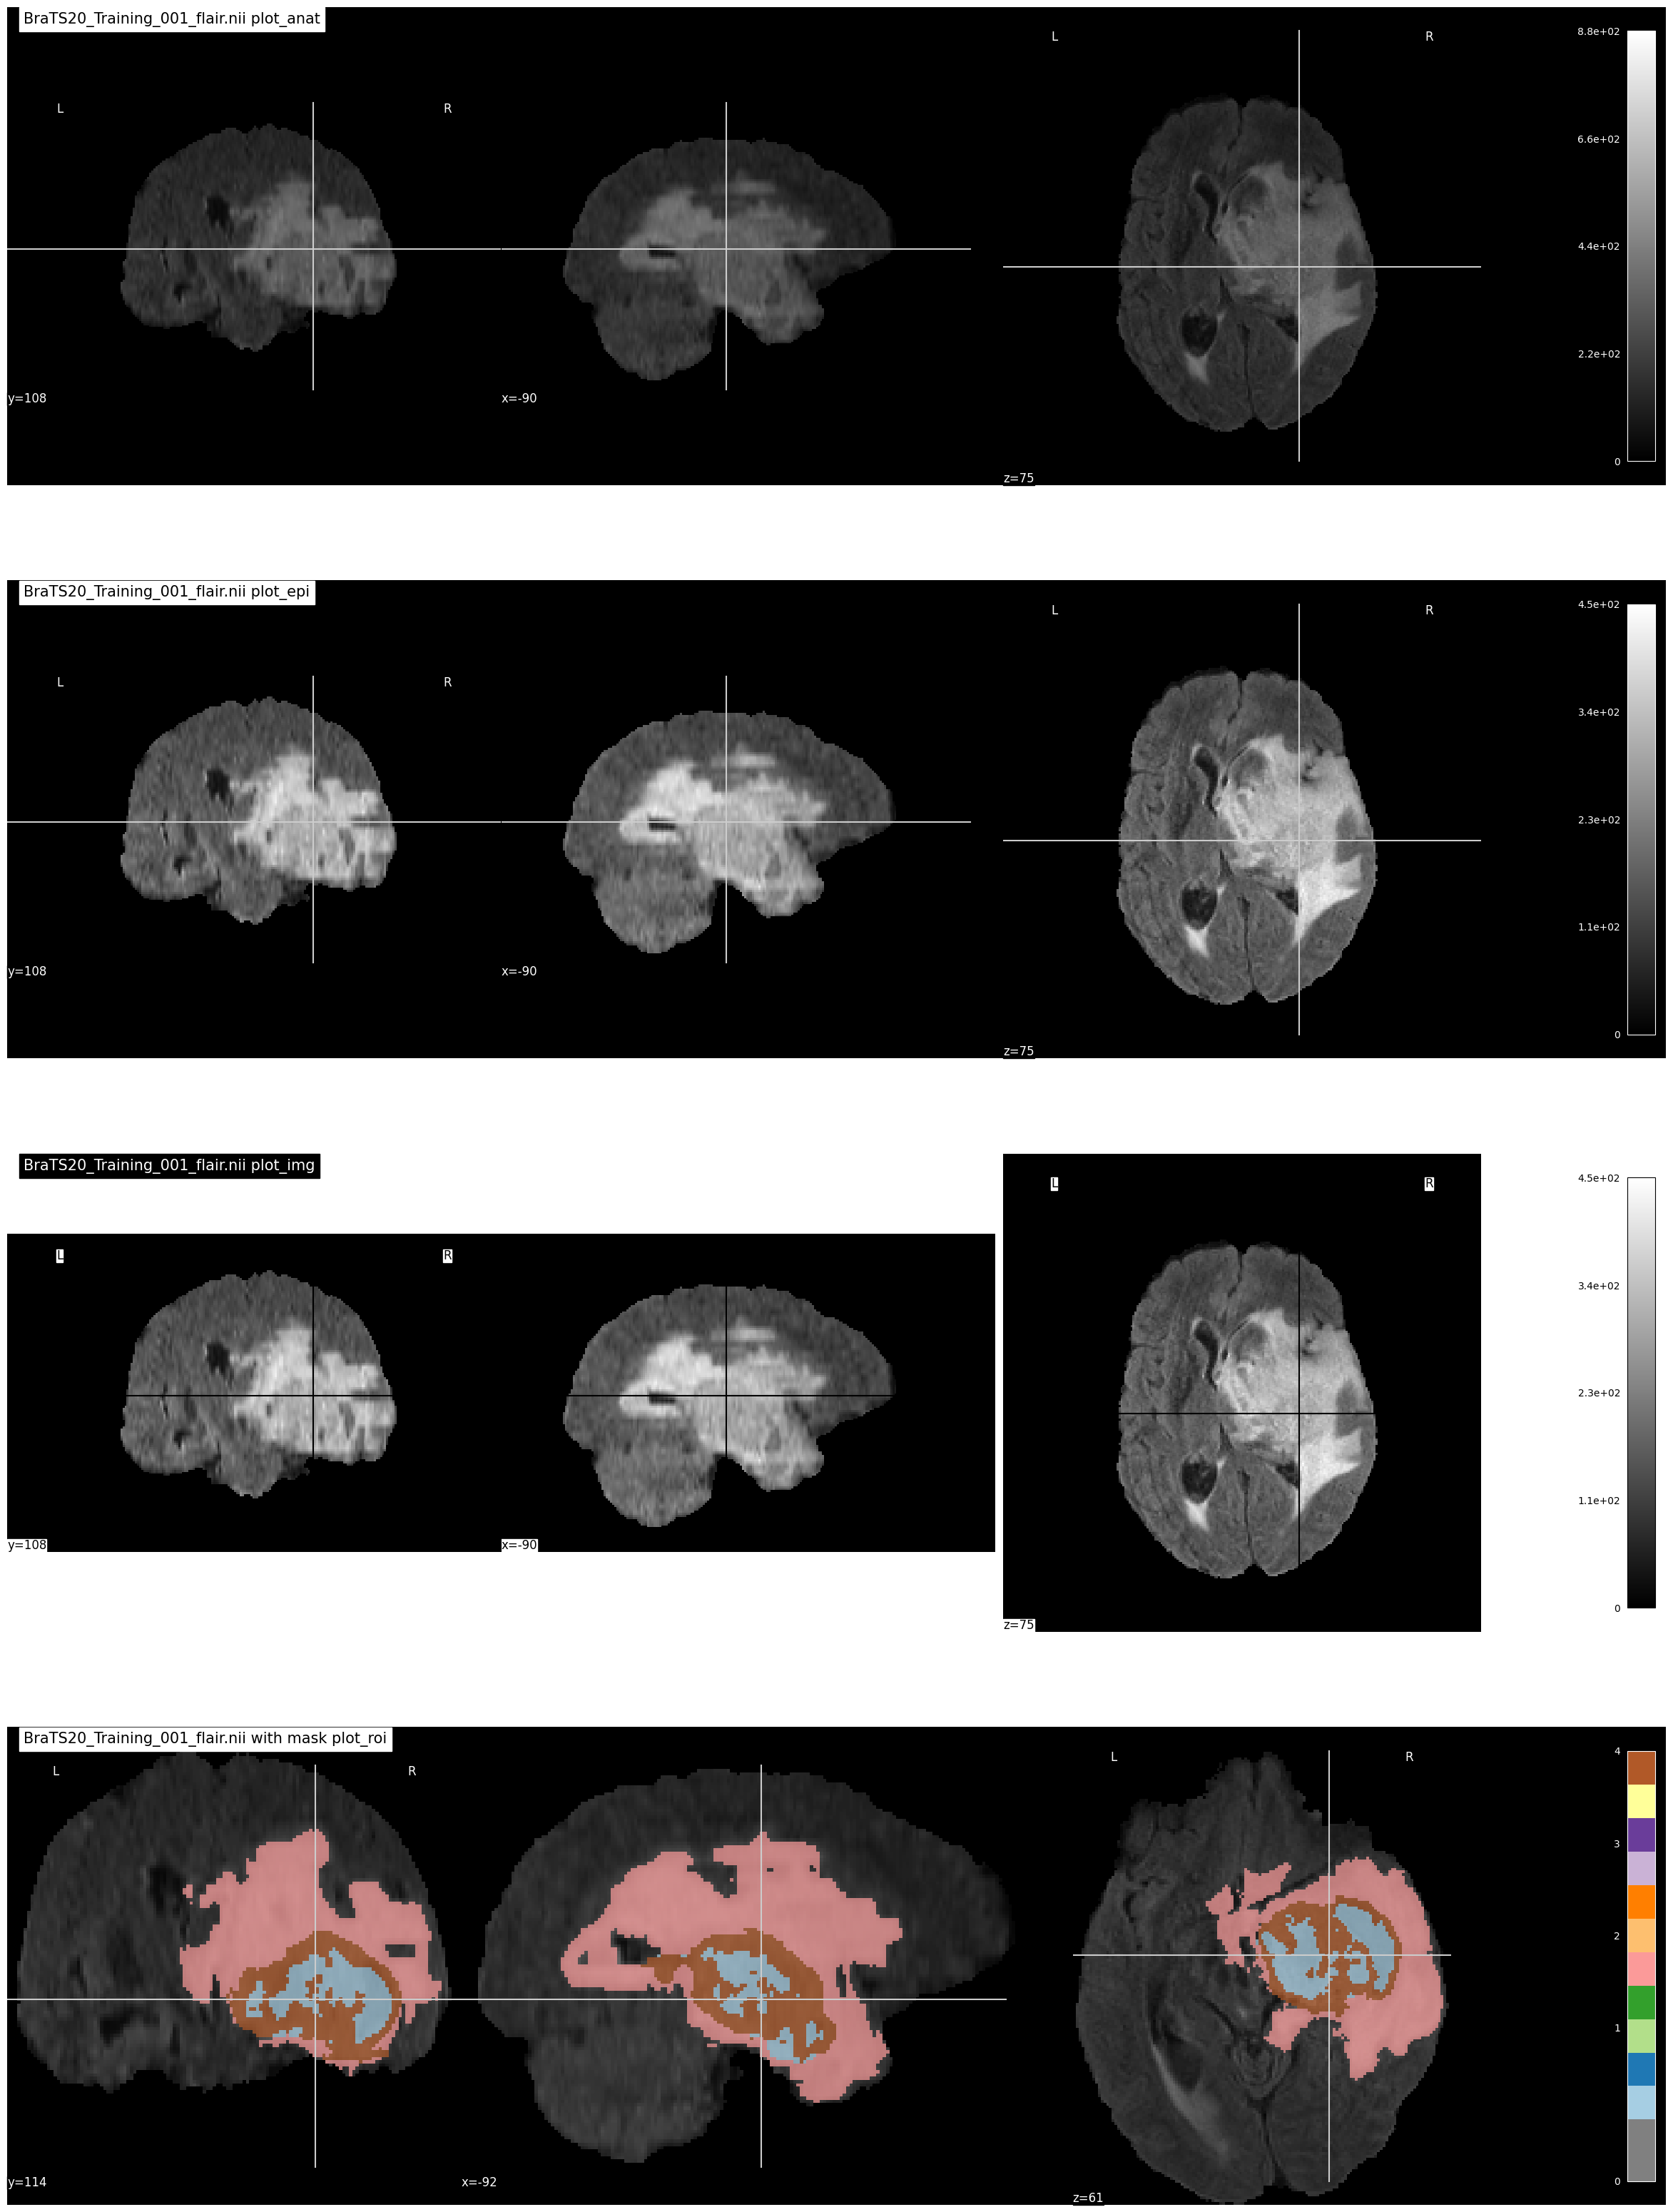

In [12]:
niimg = nl.image.load_img(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_flair.nii')
nimask = nl.image.load_img(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_seg.nii')

fig, axes = plt.subplots(nrows=4, figsize=(30, 40))


nlplt.plot_anat(niimg,
                title='BraTS20_Training_001_flair.nii plot_anat',
                axes=axes[0])

nlplt.plot_epi(niimg,
               title='BraTS20_Training_001_flair.nii plot_epi',
               axes=axes[1])

nlplt.plot_img(niimg,
               title='BraTS20_Training_001_flair.nii plot_img',
               axes=axes[2])

nlplt.plot_roi(nimask,
               title='BraTS20_Training_001_flair.nii with mask plot_roi',
               bg_img=niimg,
               axes=axes[3], cmap='Paired')

plt.show()

# Create model || U-Net: Convolutional Networks for Biomedical Image Segmentation
he u-net is convolutional network architecture for fast and precise segmentation of images. Up to now it has outperformed the prior best method (a sliding-window convolutional network) on the ISBI challenge for segmentation of neuronal structures in electron microscopic stacks. It has won the Grand Challenge for Computer-Automated Detection of Caries in Bitewing Radiography at ISBI 2015, and it has won the Cell Tracking Challenge at ISBI 2015 on the two most challenging transmitted light microscopy categories (Phase contrast and DIC microscopy) by a large margin
[more on](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/)
![official definiton](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png)


# Loss function
**Dice coefficient**
, which is essentially a measure of overlap between two samples. This measure ranges from 0 to 1 where a Dice coefficient of 1 denotes perfect and complete overlap. The Dice coefficient was originally developed for binary data, and can be calculated as:

![dice loss](https://wikimedia.org/api/rest_v1/media/math/render/svg/a80a97215e1afc0b222e604af1b2099dc9363d3b)

**As matrices**
![dice loss](https://www.jeremyjordan.me/content/images/2018/05/intersection-1.png)

[Implementation, (images above) and explanation can be found here](https://www.jeremyjordan.me/semantic-segmentation/)

In [13]:
# dice loss as defined above for 4 classes
def dice_coef(y_true, y_pred, smooth=1.0):
    class_num = 4
    for i in range(class_num):
        y_true_f = K.flatten(y_true[:,:,:,i])
        y_pred_f = K.flatten(y_pred[:,:,:,i])
        intersection = K.sum(y_true_f * y_pred_f)
        loss = ((2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth))
   #     K.print_tensor(loss, message='loss value for class {} : '.format(SEGMENT_CLASSES[i]))
        if i == 0:
            total_loss = loss
        else:
            total_loss = total_loss + loss
    total_loss = total_loss / class_num
#    K.print_tensor(total_loss, message=' total dice coef: ')
    return total_loss



# define per class evaluation of dice coef
# inspired by https://github.com/keras-team/keras/issues/9395
def dice_coef_necrotic(y_true, y_pred, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[:,:,:,1] * y_pred[:,:,:,1]))
    return (2. * intersection) / (K.sum(K.square(y_true[:,:,:,1])) + K.sum(K.square(y_pred[:,:,:,1])) + epsilon)

def dice_coef_edema(y_true, y_pred, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[:,:,:,2] * y_pred[:,:,:,2]))
    return (2. * intersection) / (K.sum(K.square(y_true[:,:,:,2])) + K.sum(K.square(y_pred[:,:,:,2])) + epsilon)

def dice_coef_enhancing(y_true, y_pred, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[:,:,:,3] * y_pred[:,:,:,3]))
    return (2. * intersection) / (K.sum(K.square(y_true[:,:,:,3])) + K.sum(K.square(y_pred[:,:,:,3])) + epsilon)



# Computing Precision
def precision(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = true_positives / (predicted_positives + K.epsilon())
        return precision


# Computing Sensitivity
def sensitivity(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    return true_positives / (possible_positives + K.epsilon())


# Computing Specificity
def specificity(y_true, y_pred):
    true_negatives = K.sum(K.round(K.clip((1-y_true) * (1-y_pred), 0, 1)))
    possible_negatives = K.sum(K.round(K.clip(1-y_true, 0, 1)))
    return true_negatives / (possible_negatives + K.epsilon())

In [14]:
import tensorflow as tf
import keras
import keras.backend as K

# --- PHẦN 1: ĐỊNH NGHĨA LẠI CÁC HÀM METRICS (SỬA LỖI K.flatten) ---

def dice_coef(y_true, y_pred, smooth=1.0):
    class_num = 4
    # Chuyển về cùng kiểu dữ liệu
    y_true = tf.cast(y_true, y_pred.dtype)

    total_loss = 0
    for i in range(class_num):
        # FIX: Thay K.flatten bằng tf.reshape cho Keras 3
        y_true_f = tf.reshape(y_true[:,:,:,i], [-1])
        y_pred_f = tf.reshape(y_pred[:,:,:,i], [-1])

        intersection = tf.reduce_sum(y_true_f * y_pred_f)
        loss = ((2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth))

        if i == 0:
            total_loss = loss
        else:
            total_loss = total_loss + loss

    total_loss = total_loss / class_num
    return total_loss

def dice_coef_necrotic(y_true, y_pred, epsilon=1e-6):
    y_true = tf.cast(y_true, y_pred.dtype)
    # FIX: Thay K.sum/abs bằng tf.reduce_sum/tf.abs cho an toàn
    intersection = tf.reduce_sum(tf.abs(y_true[:,:,:,1] * y_pred[:,:,:,1]))
    return (2. * intersection) / (tf.reduce_sum(tf.square(y_true[:,:,:,1])) + tf.reduce_sum(tf.square(y_pred[:,:,:,1])) + epsilon)

def dice_coef_edema(y_true, y_pred, epsilon=1e-6):
    y_true = tf.cast(y_true, y_pred.dtype)
    intersection = tf.reduce_sum(tf.abs(y_true[:,:,:,2] * y_pred[:,:,:,2]))
    return (2. * intersection) / (tf.reduce_sum(tf.square(y_true[:,:,:,2])) + tf.reduce_sum(tf.square(y_pred[:,:,:,2])) + epsilon)

def dice_coef_enhancing(y_true, y_pred, epsilon=1e-6):
    y_true = tf.cast(y_true, y_pred.dtype)
    intersection = tf.reduce_sum(tf.abs(y_true[:,:,:,3] * y_pred[:,:,:,3]))
    return (2. * intersection) / (tf.reduce_sum(tf.square(y_true[:,:,:,3])) + tf.reduce_sum(tf.square(y_pred[:,:,:,3])) + epsilon)

In [15]:
IMG_SIZE=128

In [16]:

def build_unet(inputs, ker_init, dropout):
    conv1 = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(inputs)
    conv1 = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv1)

    pool = MaxPooling2D(pool_size=(2, 2))(conv1)
    conv = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool)
    conv = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv)

    pool1 = MaxPooling2D(pool_size=(2, 2))(conv)
    conv2 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool1)
    conv2 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv2)

    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool2)
    conv3 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv3)


    pool4 = MaxPooling2D(pool_size=(2, 2))(conv3)
    conv5 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool4)
    conv5 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv5)
    drop5 = Dropout(dropout)(conv5)

    up7 = Conv2D(256, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(drop5))
    merge7 = concatenate([conv3,up7], axis = 3)
    conv7 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge7)
    conv7 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv7)

    up8 = Conv2D(128, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(conv7))
    merge8 = concatenate([conv2,up8], axis = 3)
    conv8 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge8)
    conv8 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv8)

    up9 = Conv2D(64, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(conv8))
    merge9 = concatenate([conv,up9], axis = 3)
    conv9 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge9)
    conv9 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv9)

    up = Conv2D(32, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(conv9))
    merge = concatenate([conv1,up], axis = 3)
    conv = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge)
    conv = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv)

    conv10 = Conv2D(4, (1,1), activation = 'softmax')(conv)

    return Model(inputs = inputs, outputs = conv10)

input_layer = Input((IMG_SIZE, IMG_SIZE, 2))

model = build_unet(input_layer, 'he_normal', 0.2)
model.compile(loss="categorical_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.001), metrics = ['accuracy',tf.keras.metrics.MeanIoU(num_classes=4), dice_coef, precision, sensitivity, specificity, dice_coef_necrotic, dice_coef_edema ,dice_coef_enhancing] )

**model architecture** <br>
If you are about to use U-NET, I suggest to check out this awesome library that I found later, after manual implementation of U-NET [keras-unet-collection](https://pypi.org/project/keras-unet-collection/), which also contains implementation of dice loss, tversky loss and many more!

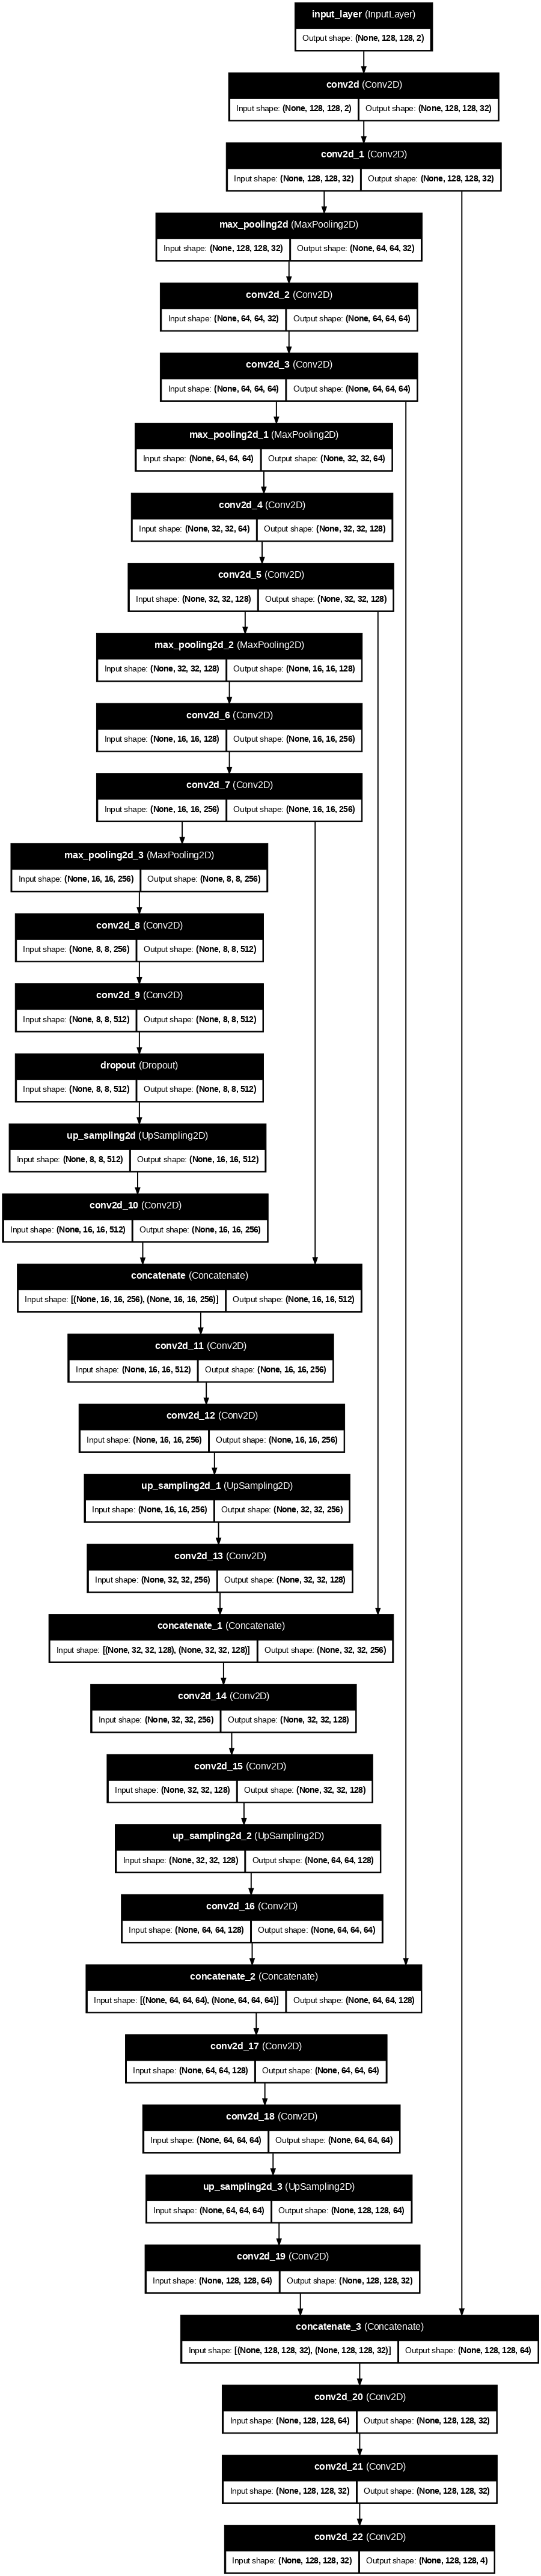

In [17]:
plot_model(model,
           show_shapes = True,
           show_dtype=False,
           show_layer_names = True,
           rankdir = 'TB',
           expand_nested = False,
           dpi = 70)

In [18]:
from tensorflow.keras.utils import to_categorical
class DataGenerator(tf.keras.utils.Sequence):
    'Generates data for Keras'
    def __init__(self, list_IDs, batch_size=4, dim=(160,192,128), n_channels=4, n_classes=4, shuffle=True, augmentation=False, patch_size=128, n_patches=1):
        'Initialization'
        self.list_IDs = list_IDs
        self.batch_size = batch_size
        self.dim = dim
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.shuffle = shuffle
        self.augmentation = augmentation
        self.patch_size = patch_size
        self.n_patches = n_patches
        self.on_epoch_end()

    def __len__(self):
        'Denotes the number of batches per epoch'
        return len(self.list_IDs) // self.batch_size

    def __getitem__(self, index):
        'Generate one batch of data'
        # Generate indexes of the batch
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]

        # Find list of IDs
        list_IDs_temp = [self.list_IDs[k] for k in indexes]

        # Generate data
        X, y = self.__data_generation(list_IDs_temp)
        if self.augmentation == True:
            X, y = self.__data_augmentation(X, y)

        if index == self.__len__()-1:
            self.on_epoch_end()

        return X, y

    def on_epoch_end(self):
        'Updates indexes after each epoch'
        self.indexes = np.arange(len(self.list_IDs))
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

    def __data_generation(self, list_IDs_temp):
        'Generates data containing batch_size samples' # X : (n_samples, *dim, n_channels)
        # Initialization
        X = np.empty((self.batch_size, *self.dim, self.n_channels))
        y = np.empty((self.batch_size, *self.dim))

        # Generate data
        for i, IDs in enumerate(list_IDs_temp):
            # Store sample
            X[i], y[i] = load_img(IDs)

        if self.augmentation == True:
            return X.astype('float32'), y
        else:
            return X.astype('float32'), to_categorical(y, self.n_classes)

    def __data_augmentation(self, X, y):
        'Apply augmentation'
        X_aug, y_aug = patch_extraction(X, y, sizePatches=self.patch_size, Npatches=self.n_patches)
        X_aug, y_aug = aug_batch(X_aug, y_aug)

        return X_aug, to_categorical(y_aug, self.n_classes)

In [19]:
sets = {'train': [], 'valid': []}
train_gen = DataGenerator(sets['train'], batch_size=1, n_classes=4, augmentation=True)
valid_gen = DataGenerator(sets['valid'], batch_size=1, n_classes=4, augmentation=True)

# Load data
Loading all data into memory is not a good idea since the data are too big to fit in.
So we will create dataGenerators - load data on the fly as explained [here](https://stanford.edu/~shervine/blog/keras-how-to-generate-data-on-the-fly)

In [20]:
# lists of directories with studies
train_and_val_directories = [f.path for f in os.scandir(TRAIN_DATASET_PATH) if f.is_dir()]

# file BraTS20_Training_355 has ill formatted name for for seg.nii file
train_and_val_directories.remove(TRAIN_DATASET_PATH+'BraTS20_Training_355')


def pathListIntoIds(dirList):
    x = []
    for i in range(0,len(dirList)):
        x.append(dirList[i][dirList[i].rfind('/')+1:])
    return x

train_and_test_ids = pathListIntoIds(train_and_val_directories);


train_test_ids, val_ids = train_test_split(train_and_test_ids,test_size=0.2)
train_ids, test_ids = train_test_split(train_test_ids,test_size=0.15)

**Override Keras sequence DataGenerator class**

In [21]:
"""
class DataGenerator(keras.utils.Sequence):
    'Generates data for Keras'
    def __init__(self, list_IDs, dim=(IMG_SIZE,IMG_SIZE), batch_size = 1, n_channels = 2, shuffle=True, **kwargs):
        'Initialization'
        # FIX: Gọi super init để tránh UserWarning
        super().__init__(**kwargs)

        self.dim = dim
        self.batch_size = batch_size
        self.list_IDs = list_IDs
        self.n_channels = n_channels
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        'Denotes the number of batches per epoch'
        return int(np.floor(len(self.list_IDs) / self.batch_size))

    def __getitem__(self, index):
        'Generate one batch of data'
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        Batch_ids = [self.list_IDs[k] for k in indexes]
        X, y = self.__data_generation(Batch_ids)
        return X, y

    def on_epoch_end(self):
        'Updates indexes after each epoch'
        self.indexes = np.arange(len(self.list_IDs))
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

    def __data_generation(self, Batch_ids):
        'Generates data containing batch_size samples'
        X = np.zeros((self.batch_size*VOLUME_SLICES, *self.dim, self.n_channels))
        y = np.zeros((self.batch_size*VOLUME_SLICES, 240, 240))

        for c, i in enumerate(Batch_ids):
            case_path = os.path.join(TRAIN_DATASET_PATH, i)

            # Load data (Đảm bảo đường dẫn TRAIN_DATASET_PATH đã đúng từ các bước trước)
            flair = nib.load(os.path.join(case_path, f'{i}_flair.nii')).get_fdata()
            ce = nib.load(os.path.join(case_path, f'{i}_t1ce.nii')).get_fdata()
            seg = nib.load(os.path.join(case_path, f'{i}_seg.nii')).get_fdata()

            for j in range(VOLUME_SLICES):
                 X[j +VOLUME_SLICES*c,:,:,0] = cv2.resize(flair[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE))
                 X[j +VOLUME_SLICES*c,:,:,1] = cv2.resize(ce[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE))
                 y[j +VOLUME_SLICES*c] = seg[:,:,j+VOLUME_START_AT]

        # Generate masks
        y[y==4] = 3
        mask = tf.one_hot(y, 4)
        Y = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE))

        # Chuẩn hóa đơn giản để tránh NaN/Inf
        max_val = np.max(X)
        if max_val > 0:
            X = X / max_val

        return X, Y

training_generator = DataGenerator(train_ids)
valid_generator = DataGenerator(val_ids)
test_generator = DataGenerator(test_ids)
"""

"\nclass DataGenerator(keras.utils.Sequence):\n    'Generates data for Keras'\n    def __init__(self, list_IDs, dim=(IMG_SIZE,IMG_SIZE), batch_size = 1, n_channels = 2, shuffle=True, **kwargs):\n        'Initialization'\n        # FIX: Gọi super init để tránh UserWarning\n        super().__init__(**kwargs)\n\n        self.dim = dim\n        self.batch_size = batch_size\n        self.list_IDs = list_IDs\n        self.n_channels = n_channels\n        self.shuffle = shuffle\n        self.on_epoch_end()\n\n    def __len__(self):\n        'Denotes the number of batches per epoch'\n        return int(np.floor(len(self.list_IDs) / self.batch_size))\n\n    def __getitem__(self, index):\n        'Generate one batch of data'\n        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]\n        Batch_ids = [self.list_IDs[k] for k in indexes]\n        X, y = self.__data_generation(Batch_ids)\n        return X, y\n\n    def on_epoch_end(self):\n        'Updates indexes after eac

**Number of data used**
for training / testing / validation

LOSS

In [22]:
def diceLoss(y_true, y_pred, class_weights):
    y_true = tf.convert_to_tensor(y_true, 'float32')
    y_pred = tf.convert_to_tensor(y_pred, y_true.dtype)

    num = tf.math.reduce_sum(tf.math.multiply(class_weights, tf.math.reduce_sum(tf.math.multiply(y_true, y_pred), axis=[0,1,2,3])))
    den = tf.math.reduce_sum(tf.math.multiply(class_weights, tf.math.reduce_sum(tf.math.add(y_true, y_pred), axis=[0,1,2,3])))+1e-5

    return 1-2*num/den

def discriminator_loss(disc_real_output, disc_fake_output):
    real_loss = tf.math.reduce_mean(tf.math.pow(tf.ones_like(disc_real_output) - disc_real_output, 2))
    fake_loss = tf.math.reduce_mean(tf.math.pow(tf.zeros_like(disc_fake_output) - disc_fake_output, 2))

    disc_loss = 0.5*(real_loss + fake_loss)

    return disc_loss


def generator_loss(target, gen_output, disc_fake_output, class_weights, alpha):

    # generalized dice loss
    dice_loss = diceLoss(target, gen_output, class_weights)

    # disc loss
    disc_loss = tf.math.reduce_mean(tf.math.pow(tf.ones_like(disc_fake_output) - disc_fake_output, 2))

    # total loss
    gen_loss = alpha*dice_loss + disc_loss

    return gen_loss, dice_loss, disc_loss

UTILS

In [23]:
def load_img(img_files):
    ''' Load one image and its target form file
    '''
    N = len(img_files)
    # target
    y = nib.load(img_files[N-1]).get_fdata(dtype='float32', caching='unchanged')
    y = y[40:200,34:226,8:136]
    y[y==4]=3

    X_norm = np.empty((240, 240, 155, 4))
    for channel in range(N-1):
        X = nib.load(img_files[channel]).get_fdata(dtype='float32', caching='unchanged')
        brain = X[X!=0]
        brain_norm = np.zeros_like(X) # background at -100
        norm = (brain - np.mean(brain))/np.std(brain)
        brain_norm[X!=0] = norm
        X_norm[:,:,:,channel] = brain_norm

    X_norm = X_norm[40:200,34:226,8:136,:]
    del(X, brain, brain_norm)

    return X_norm, y

MODEL****

In [24]:
import tensorflow as tf

class InstanceNormalization(tf.keras.layers.Layer):
    """
    Tự định nghĩa InstanceNormalization thay thế cho tensorflow_addons
    """
    def __init__(self, epsilon=1e-5, **kwargs):
        super(InstanceNormalization, self).__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        self.gamma = self.add_weight(
            name='gamma',
            shape=input_shape[-1:],
            initializer='ones',
            trainable=True)
        self.beta = self.add_weight(
            name='beta',
            shape=input_shape[-1:],
            initializer='zeros',
            trainable=True)

    def call(self, x):
        # Tính mean và variance trên các chiều không gian (H, W), giữ nguyên chiều batch và channels
        mean, variance = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        return self.gamma * (x - mean) / tf.sqrt(variance + self.epsilon) + self.beta

    def get_config(self):
        config = super(InstanceNormalization, self).get_config()
        config.update({'epsilon': self.epsilon})
        return config

In [25]:
def Generator():
    '''
    Generator model
    '''
    def encoder_step(layer, Nf, ks, norm=True):
        x = Conv3D(Nf, kernel_size=ks, strides=2, kernel_initializer='he_normal', padding='same')(layer)
        if norm:
            x = InstanceNormalization()(x)
        x = LeakyReLU()(x)
        x = Dropout(0.2)(x)

        return x

    def bottlenek(layer, Nf, ks):
        x = Conv3D(Nf, kernel_size=ks, strides=2, kernel_initializer='he_normal', padding='same')(layer)
        x = InstanceNormalization()(x)
        x = LeakyReLU()(x)
        for i in range(4):
            y = Conv3D(Nf, kernel_size=ks, strides=1, kernel_initializer='he_normal', padding='same')(x)
            x = InstanceNormalization()(y)
            x = LeakyReLU()(x)
            x = Concatenate()([x, y])

        return x

    def decoder_step(layer, layer_to_concatenate, Nf, ks):
        x = Conv3DTranspose(Nf, kernel_size=ks, strides=2, padding='same', kernel_initializer='he_normal')(layer)
        x = InstanceNormalization()(x)
        x = LeakyReLU()(x)
        x = Concatenate()([x, layer_to_concatenate])
        x = Dropout(0.2)(x)
        return x

    layers_to_concatenate = []
    inputs = Input((128,128,128,4), name='input_image')
    Nfilter_start = 64
    depth = 4
    ks = 4
    x = inputs

    # encoder
    for d in range(depth-1):
        if d==0:
            x = encoder_step(x, Nfilter_start*np.power(2,d), ks, False)
        else:
            x = encoder_step(x, Nfilter_start*np.power(2,d), ks)
        layers_to_concatenate.append(x)

    # bottlenek
    x = bottlenek(x, Nfilter_start*np.power(2,depth-1), ks)

    # decoder
    for d in range(depth-2, -1, -1):
        x = decoder_step(x, layers_to_concatenate.pop(), Nfilter_start*np.power(2,d), ks)

    # classifier
    last = Conv3DTranspose(4, kernel_size=ks, strides=2, padding='same', kernel_initializer='he_normal', activation='softmax', name='output_generator')(x)

    return Model(inputs=inputs, outputs=last, name='Generator')

def Discriminator():
    '''
    Discriminator model
    '''

    inputs = Input((128,128,128,4), name='input_image')
    targets = Input((128,128,128,4), name='target_image')
    Nfilter_start = 64
    depth = 3
    ks = 4

    def encoder_step(layer, Nf, norm=True):
        x = Conv3D(Nf, kernel_size=ks, strides=2, kernel_initializer='he_normal', padding='same')(layer)
        if norm:
            x = InstanceNormalization()(x)
        x = LeakyReLU()(x)
        x = Dropout(0.2)(x)

        return x

    x = Concatenate()([inputs, targets])

    for d in range(depth):
        if d==0:
            x = encoder_step(x, Nfilter_start*np.power(2,d), False)
        else:
            x = encoder_step(x, Nfilter_start*np.power(2,d))

    x = ZeroPadding3D()(x)
    x = Conv3D(Nfilter_start*(2**depth), ks, strides=1, padding='valid', kernel_initializer='he_normal')(x)
    x = InstanceNormalization()(x)
    x = LeakyReLU()(x)

    x = ZeroPadding3D()(x)
    last = Conv3D(1, ks, strides=1, padding='valid', kernel_initializer='he_normal', name='output_discriminator')(x)

    return Model(inputs=[targets, inputs], outputs=last, name='Discriminator')



V2V

In [26]:
import tensorflow as tf

class InstanceNormalization(tf.keras.layers.Layer):
    """
    Tự định nghĩa InstanceNormalization thay thế cho tensorflow_addons
    """
    def __init__(self, epsilon=1e-5, **kwargs):
        super(InstanceNormalization, self).__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        self.gamma = self.add_weight(
            name='gamma',
            shape=input_shape[-1:],
            initializer='ones',
            trainable=True)
        self.beta = self.add_weight(
            name='beta',
            shape=input_shape[-1:],
            initializer='zeros',
            trainable=True)

    def call(self, x):
        # Tính mean và variance trên các chiều không gian (H, W), giữ nguyên chiều batch và channels
        mean, variance = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        return self.gamma * (x - mean) / tf.sqrt(variance + self.epsilon) + self.beta

    def get_config(self):
        config = super(InstanceNormalization, self).get_config()
        config.update({'epsilon': self.epsilon})
        return config

In [27]:
import numpy as np
import nibabel as nib
import os
from tqdm import tqdm  # Thư viện hiển thị thanh tiến trình

def calculate_class_weights(ids_list, dataset_path):
    # Khởi tạo bộ đếm cho 4 lớp: 0 (Nền), 1 (NCR), 2 (ED), 3 (ET - đã map từ 4)
    # Dùng kiểu float để tránh tràn số khi cộng dồn
    total_counts = np.zeros(4, dtype=np.float64)

    print(f"Bắt đầu tính toán trên {len(ids_list)} files...")

    # Dùng tqdm để hiển thị thanh tiến trình
    for case_id in tqdm(ids_list):
        try:
            # Tạo đường dẫn tới file mask (_seg.nii)
            case_path = os.path.join(dataset_path, case_id)
            seg_path = os.path.join(case_path, f'{case_id}_seg.nii')

            # Load dữ liệu
            mask = nib.load(seg_path).get_fdata()

            # QUAN TRỌNG: Map label 4 thành 3 (giống logic trong DataGenerator của bạn)
            mask[mask == 4] = 3

            # Đếm số lượng pixel từng giá trị (0, 1, 2, 3)
            # unique: các giá trị tìm thấy, counts: số lượng tương ứng
            unique, counts = np.unique(mask, return_counts=True)

            # Cộng dồn vào tổng
            for u, c in zip(unique, counts):
                if int(u) < 4: # Chỉ lấy các nhãn hợp lệ
                    total_counts[int(u)] += c

        except Exception as e:
            print(f"Lỗi khi đọc case {case_id}: {str(e)}")
            continue

    # Tính toán trọng số theo công thức:
    # Weight_i = Tổng_pixel_toàn_bộ / (Số_lớp * Số_pixel_lớp_i)
    total_pixels = np.sum(total_counts)
    n_classes = 4

    # Thêm epsilon (1e-7) để tránh lỗi chia cho 0 nếu có lớp rỗng
    weights = total_pixels / (n_classes * (total_counts + 1e-7))

    return weights, total_counts

# --- CHẠY HÀM ---
# Sử dụng danh sách train_ids và đường dẫn bạn đã có
class_weights, pixel_counts = calculate_class_weights(train_ids, TRAIN_DATASET_PATH)

print("\n--- KẾT QUẢ ---")
print("Số lượng pixel từng lớp (0, 1, 2, 3):")
print(pixel_counts)
print("\nClass Weights đã tính toán:")
print(class_weights)

# Lưu lại file để lần sau không phải chạy lại (Tùy chọn)
# np.save('my_class_weights.npy', class_weights)

Bắt đầu tính toán trên 249 files...


100%|██████████| 249/249 [00:51<00:00,  4.80it/s]


--- KẾT QUẢ ---
Số lượng pixel từng lớp (0, 1, 2, 3):
[2.198e+09 5.714e+06 1.459e+07 4.930e+06]

Class Weights đã tính toán:
[  0.253  97.261  38.098 112.732]


In [28]:
#import tensorflow_addons as tfa
#from tensorflow_addons.layers import InstanceNormalization
import matplotlib.image as mpim
from sys import stdout

#class_weights = np.load('/kaggle/input/class-weights/class_weights.npy')
# Models
G = Generator()
D = Discriminator()

# Optimizers
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

@tf.function
def train_step(image, target, alpha):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        gen_output = G(image, training=True)

        disc_real_output = D([image, target], training=True)
        disc_fake_output = D([image, gen_output], training=True)
        disc_loss = discriminator_loss(disc_real_output, disc_fake_output)

        gen_loss, dice_loss, disc_loss_gen = generator_loss(target, gen_output, disc_fake_output, class_weights, alpha)

    generator_gradients = gen_tape.gradient(gen_loss, G.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss, D.trainable_variables)

    generator_optimizer.apply_gradients(zip(generator_gradients, G.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients, D.trainable_variables))

    return gen_loss, dice_loss, disc_loss_gen

@tf.function
def test_step(image, target, alpha):
    gen_output = G(image, training=False)

    disc_real_output = D([image, target], training=False)
    disc_fake_output = D([image, gen_output], training=False)
    disc_loss = discriminator_loss(disc_real_output, disc_fake_output)

    gen_loss, dice_loss, disc_loss_gen = generator_loss(target, gen_output, disc_fake_output, class_weights, alpha)

    return gen_loss, dice_loss, disc_loss_gen

def fit(train_gen, valid_gen, alpha = 5, epochs = 15):

    path = './RESULTS'
    if os.path.exists(path)==False:
        os.mkdir(path)

    Nt = len(train_gen)
    history = {'train': [], 'valid': []}
    prev_loss = np.inf

    epoch_v2v_loss = tf.keras.metrics.Mean()
    epoch_dice_loss = tf.keras.metrics.Mean()
    epoch_disc_loss = tf.keras.metrics.Mean()
    epoch_v2v_loss_val = tf.keras.metrics.Mean()
    epoch_dice_loss_val = tf.keras.metrics.Mean()
    epoch_disc_loss_val = tf.keras.metrics.Mean()

    for e in range(epochs):
        print('Epoch {}/{}'.format(e+1,epochs))
        b = 0
        for Xb, yb in train_gen:
            b += 1
            losses = train_step(Xb, yb, alpha)
            epoch_v2v_loss.update_state(losses[0])
            epoch_dice_loss.update_state(losses[1])
            epoch_disc_loss.update_state(losses[2])

            stdout.write('\rBatch: {}/{} - loss: {:.4f} - dice_loss: {:.4f} - disc_loss: {:.4f}'
                         .format(b, Nt, epoch_v2v_loss.result(), epoch_dice_loss.result(), epoch_disc_loss.result()))
            stdout.flush()
        history['train'].append([epoch_v2v_loss.result(), epoch_dice_loss.result(), epoch_disc_loss.result()])

        for Xb, yb in valid_gen:
            losses_val = test_step(Xb, yb, alpha)
            epoch_v2v_loss_val.update_state(losses_val[0])
            epoch_dice_loss_val.update_state(losses_val[1])
            epoch_disc_loss_val.update_state(losses_val[2])

        stdout.write('\n               loss_val: {:.4f} - dice_loss_val: {:.4f} - disc_loss_val: {:.4f}'
                     .format(epoch_v2v_loss_val.result(), epoch_dice_loss_val.result(), epoch_disc_loss_val.result()))
        stdout.flush()
        history['valid'].append([epoch_v2v_loss_val.result(), epoch_dice_loss_val.result(), epoch_disc_loss_val.result()])

        # save pred image at epoch e
        y_pred = G.predict(Xb)
        y_true = np.argmax(yb, axis=-1)
        y_pred = np.argmax(y_pred, axis=-1)

        canvas = np.zeros((128, 128*3))
        idx = np.random.randint(len(Xb))

        x = Xb[idx,:,:,64,2]
        canvas[0:128, 0:128] = (x - np.min(x))/(np.max(x)-np.min(x)+1e-6)
        canvas[0:128, 128:2*128] = y_true[idx,:,:,64]/3
        canvas[0:128, 2*128:3*128] = y_pred[idx,:,:,64]/3

        fname = (path + '/pred@epoch_{:03d}.png').format(e+1)
        mpim.imsave(fname, canvas, cmap='gray')

        # save models
        print(' ')
        if epoch_v2v_loss_val.result() < prev_loss:
            G.save_weights(path + '/Generator.h5')
            D.save_weights(path + '/Discriminator.h5')
            print("Validation loss decresaed from {:.4f} to {:.4f}. Models' weights are now saved.".format(prev_loss, epoch_v2v_loss_val.result()))
            prev_loss = epoch_v2v_loss_val.result()
        else:
            print("Validation loss did not decrese from {:.4f}.".format(prev_loss))
        print(' ')

        # resets losses states
        epoch_v2v_loss.reset_states()
        epoch_dice_loss.reset_states()
        epoch_disc_loss.reset_states()
        epoch_v2v_loss_val.reset_states()
        epoch_dice_loss_val.reset_states()
        epoch_disc_loss_val.reset_states()

        del Xb, yb, canvas, y_pred, y_true, idx

    return history ;

/tmp/ipython-input-508832832.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


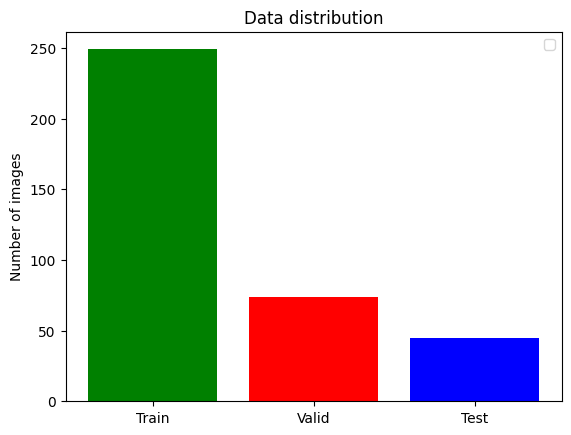

In [29]:
# show number of data for each dir
def showDataLayout():
    plt.bar(["Train","Valid","Test"],
    [len(train_ids), len(val_ids), len(test_ids)], align='center',color=[ 'green','red', 'blue'])
    plt.legend()

    plt.ylabel('Number of images')
    plt.title('Data distribution')

    plt.show()

showDataLayout()

**Add callback for training process**

In [30]:
# --- CELL 48: CẤU HÌNH CALLBACKS ---

# 1. Logger: Lưu lịch sử train vào file CSV để vẽ biểu đồ sau này
csv_logger = CSVLogger('training.log', separator=',', append=False)

# 2. Checkpoint: Luôn lưu lại phiên bản model tốt nhất (theo val_loss)
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath='model_best.h5',      # Tên file model tốt nhất
    monitor='val_loss',            # Theo dõi chỉ số val_loss
    save_best_only=True,           # Chỉ lưu khi kết quả tốt hơn trước đó
    mode='min',                    # Loss càng nhỏ càng tốt
    verbose=1
)

# 3. EarlyStopping: Dừng sớm nếu model không học thêm được nữa
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.001,
    patience=5,               # Chờ 5 epochs liên tiếp không cải thiện thì dừng
    verbose=1,
    mode='min',
    restore_best_weights=True # QUAN TRỌNG: Tự động lấy lại weights tốt nhất khi dừng
)

# 4. ReduceLROnPlateau: Giảm learning rate khi loss đi ngang
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.000001,
    verbose=1
)

# Tổng hợp danh sách callbacks
callbacks = [early_stopping, reduce_lr, checkpoint, csv_logger]

# Train model
My best model was trained with 81% accuracy on mean IOU and 65.5% on Dice loss <br>
I will load this pretrained model instead of training again

#

In [31]:
#K.clear_session()

 #history =  model.fit(training_generator,
                     #epochs=45,
                     #steps_per_epoch=len(train_ids),
                     #callbacks= callbacks,
                    #validation_data = valid_generator
                    #)
#model.save("model_per_class.h5")

**Visualize the training process**

In [34]:
# lists of directories with studies
train_and_val_directories = [f.path for f in os.scandir(TRAIN_DATASET_PATH) if f.is_dir()]

# file BraTS20_Training_355 has ill formatted name for for seg.nii file
train_and_val_directories.remove(TRAIN_DATASET_PATH+'BraTS20_Training_355')


def pathListIntoIds(dirList):
    x = []
    for i in range(0,len(dirList)):
        x.append(dirList[i][dirList[i].rfind('/')+1:])
    return x

train_and_test_ids = pathListIntoIds(train_and_val_directories);


train_test_ids, val_ids = train_test_split(train_and_test_ids,test_size=0.2)
train_ids, test_ids = train_test_split(train_test_ids,test_size=0.15)
class DataGenerator(keras.utils.Sequence):
    'Generates data for Keras'
    def __init__(self, list_IDs, dim=(IMG_SIZE,IMG_SIZE), batch_size = 1, n_channels = 2, shuffle=True, **kwargs):
        'Initialization'
        # FIX: Gọi super init để tránh UserWarning
        super().__init__(**kwargs)

        self.dim = dim
        self.batch_size = batch_size
        self.list_IDs = list_IDs
        self.n_channels = n_channels
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        'Denotes the number of batches per epoch'
        return int(np.floor(len(self.list_IDs) / self.batch_size))

    def __getitem__(self, index):
        'Generate one batch of data'
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        Batch_ids = [self.list_IDs[k] for k in indexes]
        X, y = self.__data_generation(Batch_ids)
        return X, y

    def on_epoch_end(self):
        'Updates indexes after each epoch'
        self.indexes = np.arange(len(self.list_IDs))
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

    def __data_generation(self, Batch_ids):
        'Generates data containing batch_size samples'
        X = np.zeros((self.batch_size*VOLUME_SLICES, *self.dim, self.n_channels))
        y = np.zeros((self.batch_size*VOLUME_SLICES, 240, 240))

        for c, i in enumerate(Batch_ids):
            case_path = os.path.join(TRAIN_DATASET_PATH, i)

            # Load data (Đảm bảo đường dẫn TRAIN_DATASET_PATH đã đúng từ các bước trước)
            flair = nib.load(os.path.join(case_path, f'{i}_flair.nii')).get_fdata()
            ce = nib.load(os.path.join(case_path, f'{i}_t1ce.nii')).get_fdata()
            seg = nib.load(os.path.join(case_path, f'{i}_seg.nii')).get_fdata()

            for j in range(VOLUME_SLICES):
                 X[j +VOLUME_SLICES*c,:,:,0] = cv2.resize(flair[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE))
                 X[j +VOLUME_SLICES*c,:,:,1] = cv2.resize(ce[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE))
                 y[j +VOLUME_SLICES*c] = seg[:,:,j+VOLUME_START_AT]

        # Generate masks
        y[y==4] = 3
        mask = tf.one_hot(y, 4)
        Y = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE))

        # Chuẩn hóa đơn giản để tránh NaN/Inf
        max_val = np.max(X)
        if max_val > 0:
            X = X / max_val

        return X, Y
"""
training_generator = DataGenerator(train_ids)
valid_generator = DataGenerator(val_ids)
test_generator = DataGenerator(test_ids)

history =  model.fit(training_generator,
                    epochs=45,
                    steps_per_epoch=len(train_ids),
                    callbacks= callbacks,
                    validation_data = valid_generator
                    )
model.save("/kaggle/Input/modelperclasseval/model_per_class.h5")
"""
BATCH_SIZE = 2  # Hoặc số khác tùy bạn chọn

training_generator = DataGenerator(train_ids, batch_size=BATCH_SIZE)
valid_generator = DataGenerator(val_ids, batch_size=BATCH_SIZE)
test_generator = DataGenerator(test_ids, batch_size=BATCH_SIZE)
# 2. Compile lại model để nhận diện hàm loss/metric mới
# Lưu ý: Cần đảm bảo biến 'model' và các hàm precision/sensitivity/specificity đã được định nghĩa trước đó.
# Nếu chưa, bạn cần định nghĩa lại các hàm đo đạc này tương tự như dice_coef (dùng tf.reshape/tf.reduce_sum)
model.compile(loss="categorical_crossentropy",
              optimizer=keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy',
                       tf.keras.metrics.MeanIoU(num_classes=4),
                       dice_coef,
                       #precision, sensitivity, specificity, # Tạm comment nếu các hàm này chưa được sửa
                       dice_coef_necrotic, dice_coef_edema, dice_coef_enhancing]
              )

# 3. Chạy lệnh Fit
print("Bắt đầu training...")
"""
history = model.fit(training_generator,
                    epochs=45,
                    steps_per_epoch=len(train_ids),
                    callbacks=callbacks,
                    validation_data=valid_generator
                    )
"""
history = model.fit(training_generator,
                    epochs=45,
                    # Xóa dòng steps_per_epoch hoặc để len(training_generator)
                    steps_per_epoch=len(training_generator),
                    callbacks=callbacks,
                    validation_data=valid_generator
                    )
# 4. Lưu model
model.save("model_last.h5") # Lưu vào thư mục hiện tại cho dễ tìm
print("Đã lưu model thành công!")

Bắt đầu training...
Epoch 1/45
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9651 - dice_coef: 0.2387 - dice_coef_edema: 0.0767 - dice_coef_enhancing: 0.0298 - dice_coef_necrotic: 0.0477 - loss: 0.5071 - mean_io_u_3: 0.4539
Epoch 1: val_loss improved from inf to 0.09912, saving model to model_best.h5


124/124 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.9652 - dice_coef: 0.2389 - dice_coef_edema: 0.0770 - dice_coef_enhancing: 0.0299 - dice_coef_necrotic: 0.0478 - loss: 0.5047 - mean_io_u_3: 0.4541 - val_accuracy: 0.9765 - val_dice_coef: 0.2709 - val_dice_coef_edema: 0.1121 - val_dice_coef_enhancing: 0.0273 - val_dice_coef_necrotic: 0.0446 - val_loss: 0.0991 - val_mean_io_u_3: 0.3758 - learning_rate: 0.0010
Epoch 2/45
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9801 - dice_coef: 0.2770 - dice_coef_edema: 0.1415 - dice_coef_enhancing: 0.0561 - dice_coef_necrotic: 0.0841 - loss: 0.0847 - mean_io_u_3: 0.5073
Epoch 2: val_loss improved from 0.09912 to 0.09632, saving model to model_best.h5


124/124 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.9801 - dice_coef: 0.2770 - dice_coef_edema: 0.1416 - dice_coef_enhancing: 0.0562 - dice_coef_necrotic: 0.0842 - loss: 0.0847 - mean_io_u_3: 0.5076 - val_accuracy: 0.9767 - val_dice_coef: 0.2799 - val_dice_coef_edema: 0.1912 - val_dice_coef_enhancing: 0.0854 - val_dice_coef_necrotic: 0.1109 - val_loss: 0.0963 - val_mean_io_u_3: 0.4012 - learning_rate: 0.0010
Epoch 3/45
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9799 - dice_coef: 0.2840 - dice_coef_edema: 0.1695 - dice_coef_enhancing: 0.0740 - dice_coef_necrotic: 0.1052 - loss: 0.0834 - mean_io_u_3: 0.5446
Epoch 3: val_loss improved from 0.09632 to 0.08331, saving model to model_best.h5


124/124 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.9799 - dice_coef: 0.2840 - dice_coef_edema: 0.1696 - dice_coef_enhancing: 0.0741 - dice_coef_necrotic: 0.1053 - loss: 0.0834 - mean_io_u_3: 0.5446 - val_accuracy: 0.9769 - val_dice_coef: 0.3157 - val_dice_coef_edema: 0.2634 - val_dice_coef_enhancing: 0.1176 - val_dice_coef_necrotic: 0.1633 - val_loss: 0.0833 - val_mean_io_u_3: 0.4442 - learning_rate: 0.0010
Epoch 4/45
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 993ms/step - accuracy: 0.9774 - dice_coef: 0.2855 - dice_coef_edema: 0.1609 - dice_coef_enhancing: 0.0716 - dice_coef_necrotic: 0.1094 - loss: 0.0930 - mean_io_u_3: 0.5256
Epoch 4: val_loss improved from 0.08331 to 0.08120, saving model to model_best.h5


124/124 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.9774 - dice_coef: 0.2855 - dice_coef_edema: 0.1610 - dice_coef_enhancing: 0.0716 - dice_coef_necrotic: 0.1095 - loss: 0.0930 - mean_io_u_3: 0.5261 - val_accuracy: 0.9767 - val_dice_coef: 0.3100 - val_dice_coef_edema: 0.2622 - val_dice_coef_enhancing: 0.1591 - val_dice_coef_necrotic: 0.1656 - val_loss: 0.0812 - val_mean_io_u_3: 0.6452 - learning_rate: 0.0010
Epoch 5/45
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9778 - dice_coef: 0.3109 - dice_coef_edema: 0.2450 - dice_coef_enhancing: 0.1339 - dice_coef_necrotic: 0.1647 - loss: 0.0817 - mean_io_u_3: 0.5365
Epoch 5: val_loss improved from 0.08120 to 0.07654, saving model to model_best.h5


...

124/124 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.9895 - dice_coef: 0.5381 - dice_coef_edema: 0.6591 - dice_coef_enhancing: 0.6318 - dice_coef_necrotic: 0.4607 - loss: 0.0293 - mean_io_u_3: 0.6804 - val_accuracy: 0.9878 - val_dice_coef: 0.5458 - val_dice_coef_edema: 0.7221 - val_dice_coef_enhancing: 0.6180 - val_dice_coef_necrotic: 0.4618 - val_loss: 0.0359 - val_mean_io_u_3: 0.6227 - learning_rate: 2.0000e-04
Epoch 19/45
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9893 - dice_coef: 0.5452 - dice_coef_edema: 0.6787 - dice_coef_enhancing: 0.6107 - dice_coef_necrotic: 0.4796 - loss: 0.0297 - mean_io_u_3: 0.6548
Epoch 19: val_loss did not improve from 0.03593
124/124 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.9892 - dice_coef: 0.5451 - dice_coef_edema: 0.6787 - dice_coef_enhancing: 0.6105 - dice_coef_necrotic: 0.4796 - loss: 0.0297 - mean_io_u_3: 0.6547 - val_accuracy: 0.9876 - val_dice_coef: 0.5533 - val_dice_coef_edema: 0.7182 - val_dice_coef_enhancing: 0.6127 - val

124/124 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.9899 - dice_coef: 0.5724 - dice_coef_edema: 0.6966 - dice_coef_enhancing: 0.6557 - dice_coef_necrotic: 0.5225 - loss: 0.0277 - mean_io_u_3: 0.5927 - val_accuracy: 0.9880 - val_dice_coef: 0.5679 - val_dice_coef_edema: 0.7178 - val_dice_coef_enhancing: 0.6654 - val_dice_coef_necrotic: 0.4952 - val_loss: 0.0353 - val_mean_io_u_3: 0.6495 - learning_rate: 4.0000e-05
Epoch 22/45
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9898 - dice_coef: 0.5726 - dice_coef_edema: 0.7043 - dice_coef_enhancing: 0.6527 - dice_coef_necrotic: 0.5346 - loss: 0.0278 - mean_io_u_3: 0.6799
Epoch 22: val_loss improved from 0.03535 to 0.03465, saving model to model_best.h5


124/124 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.9898 - dice_coef: 0.5726 - dice_coef_edema: 0.7043 - dice_coef_enhancing: 0.6526 - dice_coef_necrotic: 0.5345 - loss: 0.0278 - mean_io_u_3: 0.6801 - val_accuracy: 0.9885 - val_dice_coef: 0.5686 - val_dice_coef_edema: 0.7347 - val_dice_coef_enhancing: 0.6639 - val_dice_coef_necrotic: 0.4561 - val_loss: 0.0346 - val_mean_io_u_3: 0.7623 - learning_rate: 4.0000e-05
Epoch 23/45
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9901 - dice_coef: 0.5575 - dice_coef_edema: 0.7037 - dice_coef_enhancing: 0.5934 - dice_coef_necrotic: 0.5034 - loss: 0.0272 - mean_io_u_3: 0.7250
Epoch 23: val_loss did not improve from 0.03465
124/124 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.9901 - dice_coef: 0.5576 - dice_coef_edema: 0.7037 - dice_coef_enhancing: 0.5937 - dice_coef_necrotic: 0.5036 - loss: 0.0272 - mean_io_u_3: 0.7251 - val_accuracy: 0.9882 - val_dice_coef: 0.5735 - val_dice_coef_edema: 0.7494 - val_dice_coef_enhancing: 0.6223 - val

124/124 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.9899 - dice_coef: 0.5742 - dice_coef_edema: 0.7036 - dice_coef_enhancing: 0.6307 - dice_coef_necrotic: 0.5554 - loss: 0.0274 - mean_io_u_3: 0.7685 - val_accuracy: 0.9884 - val_dice_coef: 0.5798 - val_dice_coef_edema: 0.7472 - val_dice_coef_enhancing: 0.6775 - val_dice_coef_necrotic: 0.5002 - val_loss: 0.0345 - val_mean_io_u_3: 0.7693 - learning_rate: 8.0000e-06
Epoch 27/45
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9909 - dice_coef: 0.5846 - dice_coef_edema: 0.7132 - dice_coef_enhancing: 0.6824 - dice_coef_necrotic: 0.5439 - loss: 0.0258 - mean_io_u_3: 0.7641
Epoch 27: val_loss did not improve from 0.03447
124/124 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.9909 - dice_coef: 0.5846 - dice_coef_edema: 0.7132 - dice_coef_enhancing: 0.6823 - dice_coef_necrotic: 0.5437 - loss: 0.0258 - mean_io_u_3: 0.7641 - val_accuracy: 0.9882 - val_dice_coef: 0.5687 - val_dice_coef_edema: 0.7232 - val_dice_coef_enhancing: 0.6292 - val

Đã lưu model thành công!


Epoch 1/35
221/249 [=========================>....] - ETA: 42:36 - loss: 0.0910 - accuracy: 0.9801 - mean_io_u: 0.3756 - dice_coef: 0.2971 - precision: 0.9831 - sensitivity: 0.9737 - specificity: 0.9957 - dice_coef_necrotic: 0.1109 - dice_coef_edema: 0.2269 - dice_coef_enhancing: 0.0686
Epoch 1/35
221/249 [=========================>....] - ETA: 42:36 - loss: 0.0910 - accuracy: 0.9801 - mean_io_u: 0.3756 - dice_coef: 0.2971 - precision: 0.9831 - sensitivity: 0.9737 - specificity: 0.9957 - dice_coef_necrotic: 0.1109 - dice_coef_edema: 0.2269 - dice_coef_enhancing: 0.0686

Đang load model tốt nhất: model_best.h5 ...
Đang đọc lịch sử training: training.log ...
Lưu ý: Không tìm thấy cột 'mean_io_u', thử tìm các cột tương tự...


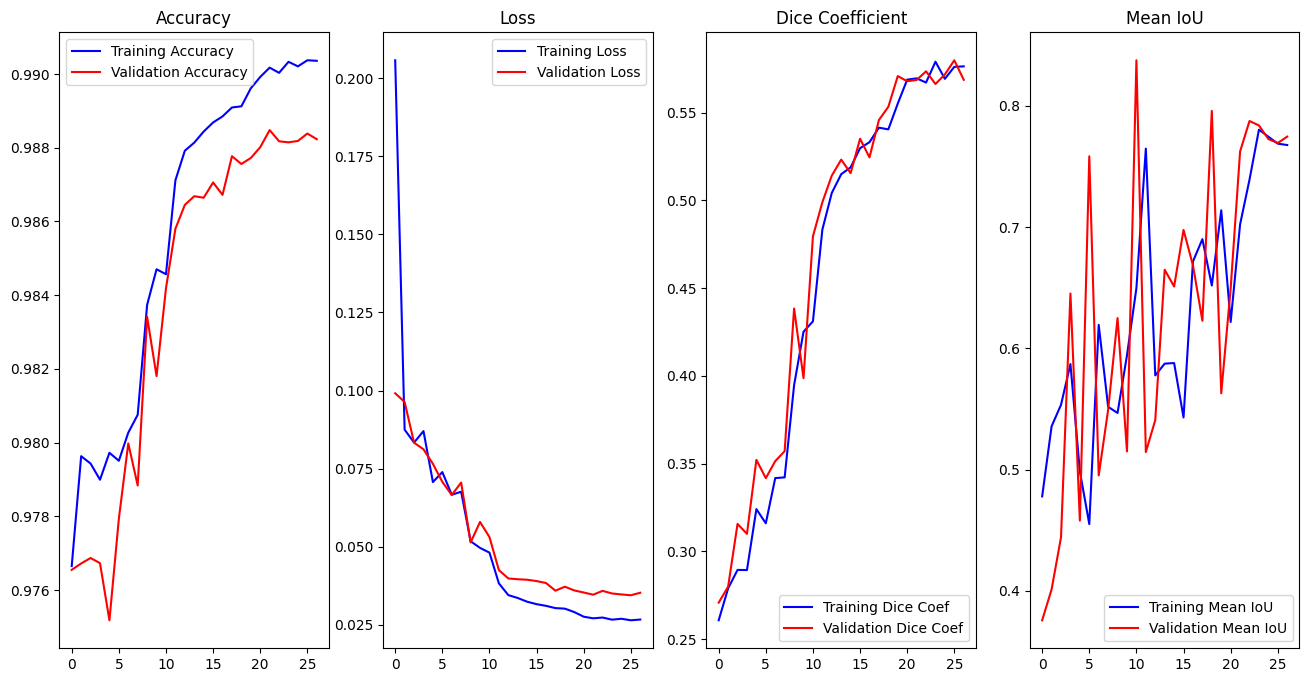

In [35]:
# --- CELL 55: ĐÁNH GIÁ KẾT QUẢ ---

# 1. Load model tốt nhất (model_best.h5) vừa train xong
# Lưu ý: Không dùng đường dẫn '../input/...' nữa vì file đang nằm ngay thư mục hiện tại
print("Đang load model tốt nhất: model_best.h5 ...")
model = keras.models.load_model('model_best.h5',
                                custom_objects={ 'accuracy' : tf.keras.metrics.MeanIoU(num_classes=4),
                                                "dice_coef": dice_coef,
                                                "precision": precision,
                                                "sensitivity":sensitivity,
                                                "specificity":specificity,
                                                "dice_coef_necrotic": dice_coef_necrotic,
                                                "dice_coef_edema": dice_coef_edema,
                                                "dice_coef_enhancing": dice_coef_enhancing
                                               }, compile=False)

# 2. Đọc file log training (training.log)
print("Đang đọc lịch sử training: training.log ...")
history = pd.read_csv('training.log', sep=',', engine='python')

# 3. Vẽ biểu đồ
hist = history

# Lấy dữ liệu các cột
acc = hist['accuracy']
val_acc = hist['val_accuracy']
loss = hist['loss']
val_loss = hist['val_loss']
train_dice = hist['dice_coef']
val_dice = hist['val_dice_coef']

epoch = range(len(acc))

f, ax = plt.subplots(1, 4, figsize=(16, 8))

# Biểu đồ Accuracy
ax[0].plot(epoch, acc, 'b', label='Training Accuracy')
ax[0].plot(epoch, val_acc, 'r', label='Validation Accuracy')
ax[0].set_title('Accuracy')
ax[0].legend()

# Biểu đồ Loss
ax[1].plot(epoch, loss, 'b', label='Training Loss')
ax[1].plot(epoch, val_loss, 'r', label='Validation Loss')
ax[1].set_title('Loss')
ax[1].legend()

# Biểu đồ Dice Coefficient
ax[2].plot(epoch, train_dice, 'b', label='Training Dice Coef')
ax[2].plot(epoch, val_dice, 'r', label='Validation Dice Coef')
ax[2].set_title('Dice Coefficient')
ax[2].legend()

# Biểu đồ Mean IoU (Kiểm tra tên cột trong file log để tránh lỗi)
if 'mean_io_u' in hist.columns:
    ax[3].plot(epoch, hist['mean_io_u'], 'b', label='Training Mean IoU')
    ax[3].plot(epoch, hist['val_mean_io_u'], 'r', label='Validation Mean IoU')
else:
    # Fallback nếu tên cột khác (do phiên bản TF)
    print("Lưu ý: Không tìm thấy cột 'mean_io_u', thử tìm các cột tương tự...")
    for col in hist.columns:
        if 'mean_io_u' in col and 'val' not in col:
             ax[3].plot(epoch, hist[col], 'b', label='Training Mean IoU')
        if 'mean_io_u' in col and 'val' in col:
             ax[3].plot(epoch, hist[col], 'r', label='Validation Mean IoU')

ax[3].set_title('Mean IoU')
ax[3].legend()

plt.show()

luu# Prediction examples

In [36]:
# mri type must one of 1) flair 2) t1 3) t1ce 4) t2 ------- or even 5) seg
# returns volume of specified study at `path`
def imageLoader(path):
    image = nib.load(path).get_fdata()
    X = np.zeros((self.batch_size*VOLUME_SLICES, *self.dim, self.n_channels))
    for j in range(VOLUME_SLICES):
        X[j +VOLUME_SLICES*c,:,:,0] = cv2.resize(image[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE));
        X[j +VOLUME_SLICES*c,:,:,1] = cv2.resize(ce[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE));

        y[j +VOLUME_SLICES*c] = seg[:,:,j+VOLUME_START_AT];
    return np.array(image)


# load nifti file at `path`
# and load each slice with mask from volume
# choose the mri type & resize to `IMG_SIZE`
def loadDataFromDir(path, list_of_files, mriType, n_images):
    scans = []
    masks = []
    for i in list_of_files[:n_images]:
        fullPath = glob.glob( i + '/*'+ mriType +'*')[0]
        currentScanVolume = imageLoader(fullPath)
        currentMaskVolume = imageLoader( glob.glob( i + '/*seg*')[0] )
        # for each slice in 3D volume, find also it's mask
        for j in range(0, currentScanVolume.shape[2]):
            scan_img = cv2.resize(currentScanVolume[:,:,j], dsize=(IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_AREA).astype('uint8')
            mask_img = cv2.resize(currentMaskVolume[:,:,j], dsize=(IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_AREA).astype('uint8')
            scans.append(scan_img[..., np.newaxis])
            masks.append(mask_img[..., np.newaxis])
    return np.array(scans, dtype='float32'), np.array(masks, dtype='float32')

#brains_list_test, masks_list_test = loadDataFromDir(VALIDATION_DATASET_PATH, test_directories, "flair", 5)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


<Figure size 1800x5000 with 0 Axes>

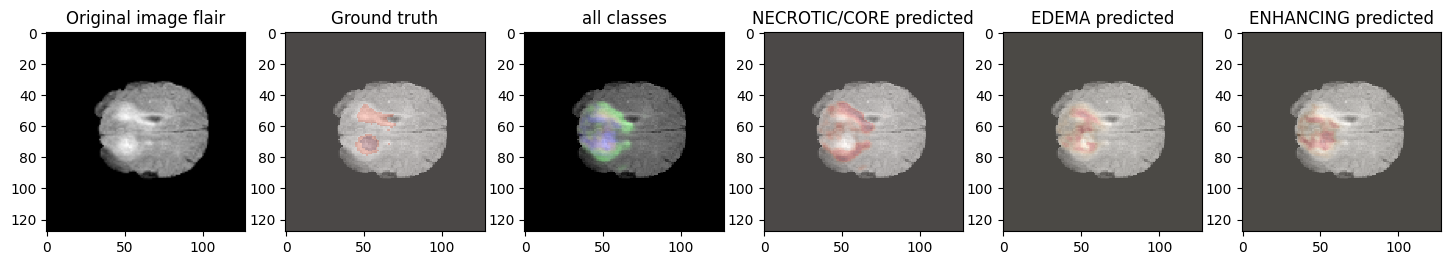

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


<Figure size 1800x5000 with 0 Axes>

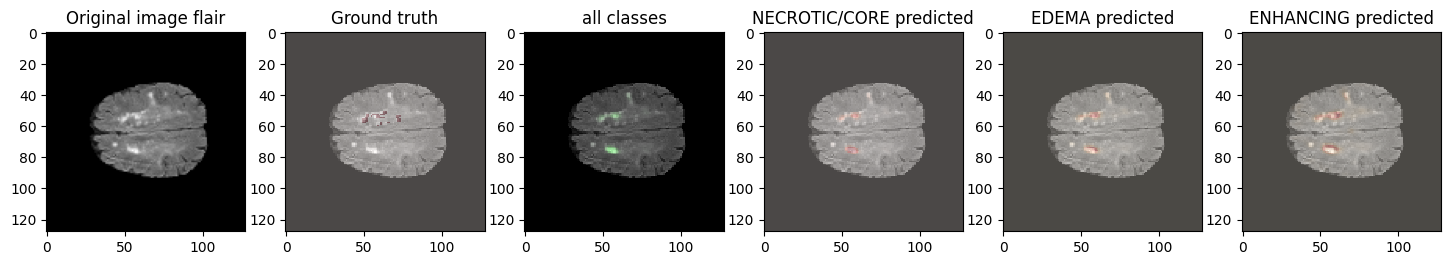

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


<Figure size 1800x5000 with 0 Axes>

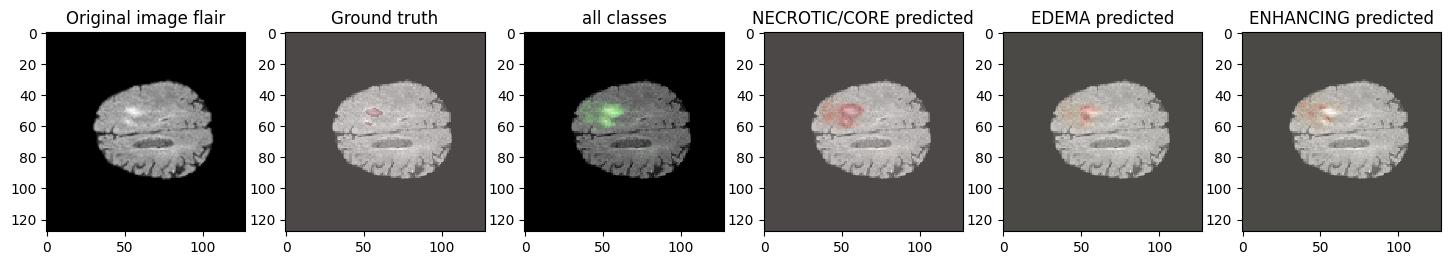

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


<Figure size 1800x5000 with 0 Axes>

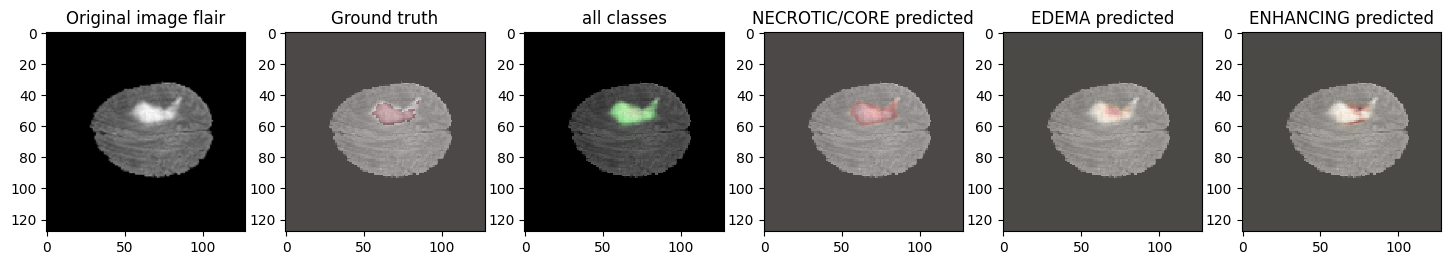

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


<Figure size 1800x5000 with 0 Axes>

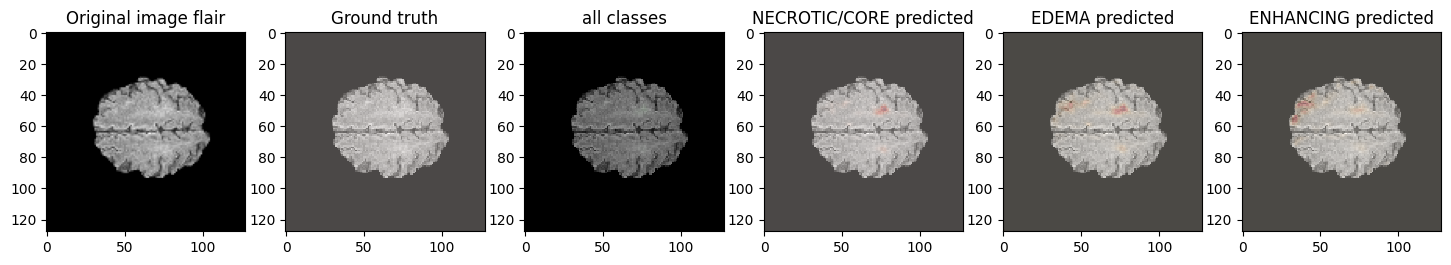

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


<Figure size 1800x5000 with 0 Axes>

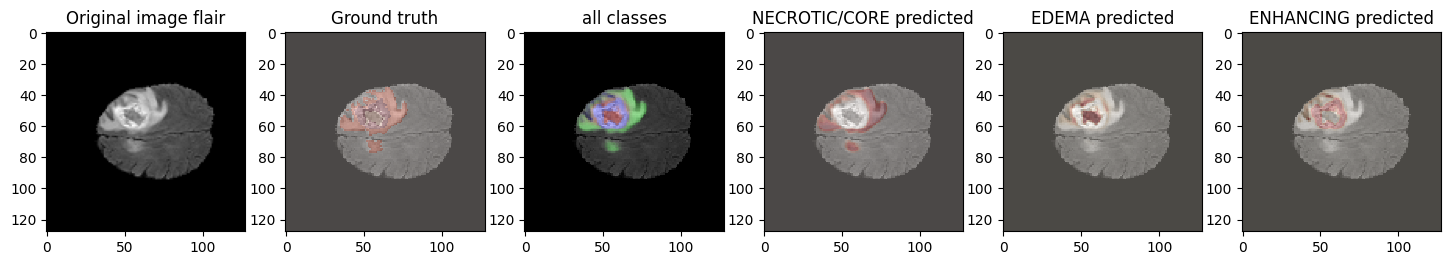

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


<Figure size 1800x5000 with 0 Axes>

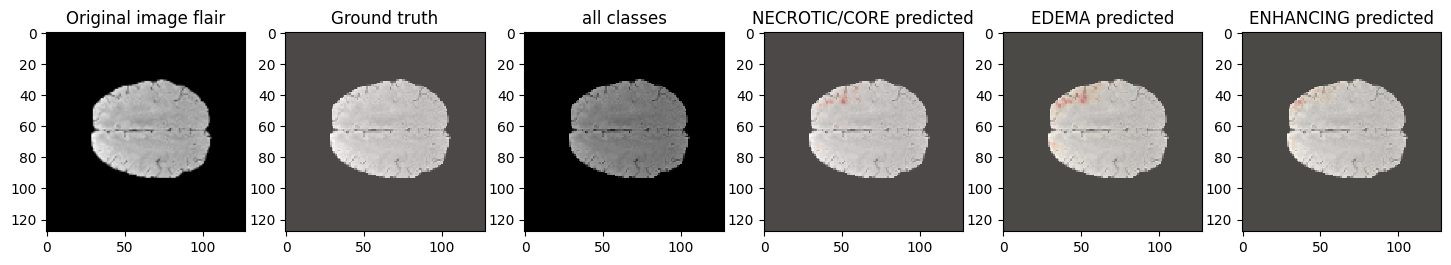

In [40]:
def predictByPath(case_path,case):
    files = next(os.walk(case_path))[2]
    X = np.empty((VOLUME_SLICES, IMG_SIZE, IMG_SIZE, 2))
  #  y = np.empty((VOLUME_SLICES, IMG_SIZE, IMG_SIZE))

    vol_path = os.path.join(case_path, f'BraTS20_Training_{case}_flair.nii');
    flair=nib.load(vol_path).get_fdata()

    vol_path = os.path.join(case_path, f'BraTS20_Training_{case}_t1ce.nii');
    ce=nib.load(vol_path).get_fdata()

 #   vol_path = os.path.join(case_path, f'BraTS20_Training_{case}_seg.nii');
 #   seg=nib.load(vol_path).get_fdata()


    for j in range(VOLUME_SLICES):
        X[j,:,:,0] = cv2.resize(flair[:,:,j+VOLUME_START_AT], (IMG_SIZE,IMG_SIZE))
        X[j,:,:,1] = cv2.resize(ce[:,:,j+VOLUME_START_AT], (IMG_SIZE,IMG_SIZE))
 #       y[j,:,:] = cv2.resize(seg[:,:,j+VOLUME_START_AT], (IMG_SIZE,IMG_SIZE))

  #  model.evaluate(x=X,y=y[:,:,:,0], callbacks= callbacks)
    return model.predict(X/np.max(X), verbose=1)


def showPredictsById(case, start_slice = 65):
    # --- SỬA LỖI TẠI ĐÂY ---
    # Thay vì dùng đường dẫn cứng sai lệch, ta dùng biến TRAIN_DATASET_PATH chuẩn
    path = os.path.join(TRAIN_DATASET_PATH, f"BraTS20_Training_{case}")

    # Load Ground Truth và Ảnh gốc từ đường dẫn mới
    gt = nib.load(os.path.join(path, f'BraTS20_Training_{case}_seg.nii')).get_fdata()
    origImage = nib.load(os.path.join(path, f'BraTS20_Training_{case}_flair.nii')).get_fdata()

    # Gọi hàm dự đoán
    p = predictByPath(path, case)

    core = p[:,:,:,1]
    edema= p[:,:,:,2]
    enhancing = p[:,:,:,3]

    plt.figure(figsize=(18, 50))
    f, axarr = plt.subplots(1,6, figsize = (18, 50))

    for i in range(6): # for each image, add brain background
        axarr[i].imshow(cv2.resize(origImage[:,:,start_slice+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE)), cmap="gray", interpolation='none')

    axarr[0].imshow(cv2.resize(origImage[:,:,start_slice+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE)), cmap="gray")
    axarr[0].title.set_text('Original image flair')
    curr_gt=cv2.resize(gt[:,:,start_slice+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE), interpolation = cv2.INTER_NEAREST)
    axarr[1].imshow(curr_gt, cmap="Reds", interpolation='none', alpha=0.3) # ,alpha=0.3,cmap='Reds'
    axarr[1].title.set_text('Ground truth')
    axarr[2].imshow(p[start_slice,:,:,1:4], cmap="Reds", interpolation='none', alpha=0.3)
    axarr[2].title.set_text('all classes')
    axarr[3].imshow(edema[start_slice,:,:], cmap="Reds", interpolation='none', alpha=0.3)
    axarr[3].title.set_text(f'{SEGMENT_CLASSES[1]} predicted')
    axarr[4].imshow(core[start_slice,:,], cmap="OrRd", interpolation='none', alpha=0.3)
    axarr[4].title.set_text(f'{SEGMENT_CLASSES[2]} predicted')
    axarr[5].imshow(enhancing[start_slice,:,], cmap="OrRd", interpolation='none', alpha=0.3)
    axarr[5].title.set_text(f'{SEGMENT_CLASSES[3]} predicted')
    plt.show()

# Chạy thử nghiệm với các case trong tập test
# Lưu ý: test_ids phải chứa chuỗi ID dạng số (ví dụ '001', '355'...)
# Code gốc dùng [-3:] để cắt chuỗi, giả định ID luôn có 3 số cuối.
showPredictsById(case=test_ids[0][-3:])
showPredictsById(case=test_ids[1][-3:])
showPredictsById(case=test_ids[2][-3:])
showPredictsById(case=test_ids[3][-3:])
showPredictsById(case=test_ids[4][-3:])
showPredictsById(case=test_ids[5][-3:])
showPredictsById(case=test_ids[6][-3:])
# Thử một case cụ thể nếu cần (đảm bảo ID này tồn tại trong folder)
# showPredictsById(case='155')

# Evaluation

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


<Figure size 1200x600 with 0 Axes>

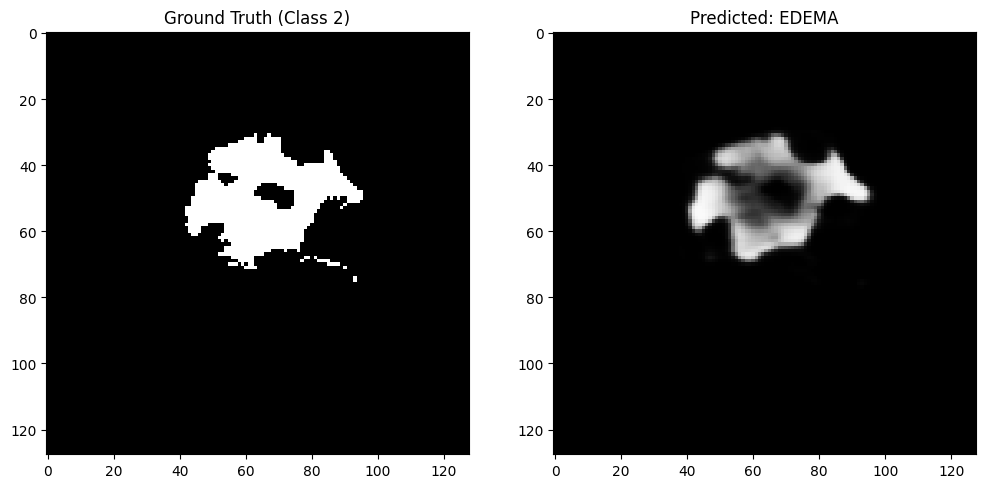

In [41]:
# 1. Sửa cú pháp lấy ID case
case = test_ids[3][-3:]

# 2. Sửa đường dẫn dùng biến chuẩn TRAIN_DATASET_PATH
path = os.path.join(TRAIN_DATASET_PATH, f"BraTS20_Training_{case}")

# Load dữ liệu nhãn gốc (Ground Truth)
gt = nib.load(os.path.join(path, f'BraTS20_Training_{case}_seg.nii')).get_fdata()

# Thực hiện dự đoán
p = predictByPath(path, case)

# Các thông số hiển thị
i = 40 # Vị trí lát cắt (slice)
eval_class = 2 #  2 : 'CORE' (Lớp lõi khối u)

# --- PHẦN SỬA LOGIC QUAN TRỌNG ---

# Bước 1: Lấy lát cắt cụ thể trước (đỡ tốn RAM xử lý cả khối 3D)
gt_slice = gt[:,:,i+VOLUME_START_AT]

# Bước 2: Tạo mặt nạ nhị phân (Binary Mask)
# Logic cũ sai: gt[gt != eval_class] = 1
# Logic mới: Nếu điểm ảnh == eval_class thì là 1 (trắng), còn lại là 0 (đen)
gt_mask = np.where(gt_slice == eval_class, 1, 0).astype(np.float32)

# Bước 3: Resize về kích thước model (128x128)
resized_gt = cv2.resize(gt_mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

# --- VẼ BIỂU ĐỒ ---
plt.figure(figsize=(12, 6)) # Tăng kích thước cho dễ nhìn
f, axarr = plt.subplots(1, 2, figsize=(12, 6))

# Ảnh bên trái: Ground Truth
axarr[0].imshow(resized_gt, cmap="gray", vmin=0, vmax=1)
axarr[0].set_title(f'Ground Truth (Class {eval_class})')

# Ảnh bên phải: Dự đoán của Model
# p[...] chứa xác suất (probability) từ 0 đến 1
axarr[1].imshow(p[i,:,:,eval_class], cmap="gray", vmin=0, vmax=1)
axarr[1].set_title(f'Predicted: {SEGMENT_CLASSES[eval_class]}')

plt.show()

In [43]:
model.compile(loss="categorical_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.001), metrics = ['accuracy',tf.keras.metrics.MeanIoU(num_classes=4), #dice_coef, precision, sensitivity, specificity,
                                                                                                                dice_coef_necrotic, dice_coef_edema, dice_coef_enhancing] )
# Evaluate the model on the test data using `evaluate`
print("Evaluate on test data")
results = model.evaluate(test_generator, batch_size=100, callbacks= callbacks)
print("test loss, test acc:", results)

Evaluate on test data
22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9885 - dice_coef_edema: 0.7005 - dice_coef_enhancing: 0.6208 - dice_coef_necrotic: 0.5576 - loss: 0.0452 - mean_io_u_6: 0.7722
test loss, test acc: [0.040810517966747284, 0.9888647198677063, 0.764127254486084, 0.47174569964408875, 0.7156055569648743, 0.6077027320861816]


# Survival prediction

Full implementation can be found in my another notebook: https://www.kaggle.com/rastislav/mri-brain-tumor-survival-prediction